In [ ]:
import sys, os
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates


In [2]:
# load the clean dataset of returns
returns = pd.read_csv(Path('data/HHub/returns_clean.csv'))
returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 4029 entries, 0 to 4028
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4029 non-null   str    
 1   hh_1    4029 non-null   float64
 2   hh_2    4029 non-null   float64
 3   hh_3    4029 non-null   float64
 4   hh_4    4029 non-null   float64
 5   hh_5    4029 non-null   float64
 6   hh_6    4029 non-null   float64
 7   hh_7    4029 non-null   float64
 8   hh_8    4029 non-null   float64
 9   hh_9    4029 non-null   float64
 10  hh_10   4029 non-null   float64
 11  hh_11   4029 non-null   float64
dtypes: float64(11), str(1)
memory usage: 417.2 KB


In [3]:
returns["Date"] = pd.to_datetime(returns["Date"])
returns.sort_values(by='Date', inplace=True)
returns.set_index('Date', inplace=True)

returns

,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
Date,,,,,,,,,,,
2010-03-05,0.003927,0.003440,0.002541,0.002909,0.003282,0.004071,0.003989,0.003753,0.004753,0.004572,0.004770
2010-03-08,-0.014474,-0.014921,-0.014913,-0.014629,-0.014231,-0.013703,-0.013426,-0.010734,-0.008289,-0.007972,-0.008020
2010-03-09,-0.002433,-0.003273,-0.003440,-0.003163,-0.003538,-0.004127,-0.004853,-0.006458,-0.006930,-0.007865,-0.008776
2010-03-10,0.009477,0.010653,0.011350,0.011340,0.011194,0.010286,0.009683,0.007215,0.005867,0.004282,0.004311
2010-03-11,-0.026449,-0.025850,-0.025230,-0.024734,-0.023148,-0.022352,-0.020895,-0.017365,-0.014823,-0.013421,-0.012293
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-26,-0.014399,-0.011496,-0.008198,-0.008105,-0.007914,-0.007652,-0.006951,-0.005373,-0.004391,-0.003843,-0.001906
2026-02-27,0.011256,0.009416,0.008525,0.005710,0.005283,0.005597,0.006084,0.006177,0.004621,0.003630,0.004045
2026-03-02,0.034717,0.035462,0.028325,0.022226,0.021718,0.022368,0.023410,0.027204,0.030869,0.031882,0.030865


In [4]:
returns.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4029 entries, 2010-03-05 to 2026-03-04
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hh_1    4029 non-null   float64
 1   hh_2    4029 non-null   float64
 2   hh_3    4029 non-null   float64
 3   hh_4    4029 non-null   float64
 4   hh_5    4029 non-null   float64
 5   hh_6    4029 non-null   float64
 6   hh_7    4029 non-null   float64
 7   hh_8    4029 non-null   float64
 8   hh_9    4029 non-null   float64
 9   hh_10   4029 non-null   float64
 10  hh_11   4029 non-null   float64
dtypes: float64(11)
memory usage: 377.7 KB


In [5]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
hh_1,4029.0,-0.000772,0.035126,-0.296448,-0.019751,-0.000694,0.017915,0.381727
hh_2,4029.0,-0.001139,0.030385,-0.238344,-0.018225,-0.000973,0.016160,0.181209
hh_3,4029.0,-0.001072,0.027906,-0.226705,-0.016489,-0.000695,0.014995,0.171313
hh_4,4029.0,-0.000731,0.025582,-0.218014,-0.014862,-0.000422,0.013978,0.186265
hh_5,4029.0,-0.000562,0.022946,-0.181722,-0.013583,-0.000210,0.012660,0.126656
hh_6,4029.0,-0.000369,0.021353,-0.176754,-0.012137,0.000000,0.011819,0.115825
hh_7,4029.0,-0.000298,0.020041,-0.175464,-0.011061,0.000330,0.010910,0.128467
hh_8,4029.0,-0.000273,0.018851,-0.180258,-0.010414,0.000330,0.010188,0.144858
hh_9,4029.0,-0.000195,0.017870,-0.193866,-0.009615,0.000563,0.009596,0.141780
hh_10,4029.0,-0.000241,0.017220,-0.325734,-0.008804,0.000530,0.009035,0.120144


In [6]:
returns.isna().sum()

hh_1     0
hh_2     0
hh_3     0
hh_4     0
hh_5     0
hh_6     0
hh_7     0
hh_8     0
hh_9     0
hh_10    0
hh_11    0
dtype: int64

# Statistical Factor Model

In [7]:
returns

,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
Date,,,,,,,,,,,
2010-03-05,0.003927,0.003440,0.002541,0.002909,0.003282,0.004071,0.003989,0.003753,0.004753,0.004572,0.004770
2010-03-08,-0.014474,-0.014921,-0.014913,-0.014629,-0.014231,-0.013703,-0.013426,-0.010734,-0.008289,-0.007972,-0.008020
2010-03-09,-0.002433,-0.003273,-0.003440,-0.003163,-0.003538,-0.004127,-0.004853,-0.006458,-0.006930,-0.007865,-0.008776
2010-03-10,0.009477,0.010653,0.011350,0.011340,0.011194,0.010286,0.009683,0.007215,0.005867,0.004282,0.004311
2010-03-11,-0.026449,-0.025850,-0.025230,-0.024734,-0.023148,-0.022352,-0.020895,-0.017365,-0.014823,-0.013421,-0.012293
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-26,-0.014399,-0.011496,-0.008198,-0.008105,-0.007914,-0.007652,-0.006951,-0.005373,-0.004391,-0.003843,-0.001906
2026-02-27,0.011256,0.009416,0.008525,0.005710,0.005283,0.005597,0.006084,0.006177,0.004621,0.003630,0.004045
2026-03-02,0.034717,0.035462,0.028325,0.022226,0.021718,0.022368,0.023410,0.027204,0.030869,0.031882,0.030865


## Setup — Clean Return Matrix for Factor Model

In [8]:
price_cols = [col for col in returns.columns if col.startswith("hh")]
X_df   = returns[price_cols]   # DataFrame T x N
N      = len(price_cols)                                # 12 maturities
mats   = [f"M{i}" for i in range(1, N + 1)]

print(f"Return matrix : {X_df.shape[0]} dates × {N} maturities")
print(f"Period        : {X_df.index[0].date()} → {X_df.index[-1].date()}")

Return matrix : 4029 dates × 11 maturities
Period        : 2010-03-05 → 2026-03-04


## 1. Rolling Window Diagnostics — Choosing T

Before fitting the full model, compare rolling PCA stability for T ∈ {126, 252, 504}.

Diagnostics:
- Explained variance ratio (EVR) per factor through time
- Eigenvalue paths
- |Cosine similarity| between consecutive loading vectors — measures factor stability

In [9]:
X_df

,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
Date,,,,,,,,,,,
2010-03-05,0.003927,0.003440,0.002541,0.002909,0.003282,0.004071,0.003989,0.003753,0.004753,0.004572,0.004770
2010-03-08,-0.014474,-0.014921,-0.014913,-0.014629,-0.014231,-0.013703,-0.013426,-0.010734,-0.008289,-0.007972,-0.008020
2010-03-09,-0.002433,-0.003273,-0.003440,-0.003163,-0.003538,-0.004127,-0.004853,-0.006458,-0.006930,-0.007865,-0.008776
2010-03-10,0.009477,0.010653,0.011350,0.011340,0.011194,0.010286,0.009683,0.007215,0.005867,0.004282,0.004311
2010-03-11,-0.026449,-0.025850,-0.025230,-0.024734,-0.023148,-0.022352,-0.020895,-0.017365,-0.014823,-0.013421,-0.012293
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-26,-0.014399,-0.011496,-0.008198,-0.008105,-0.007914,-0.007652,-0.006951,-0.005373,-0.004391,-0.003843,-0.001906
2026-02-27,0.011256,0.009416,0.008525,0.005710,0.005283,0.005597,0.006084,0.006177,0.004621,0.003630,0.004045
2026-03-02,0.034717,0.035462,0.028325,0.022226,0.021718,0.022368,0.023410,0.027204,0.030869,0.031882,0.030865


In [10]:
def rolling_pca_diagnostics(X_df, window, n_components=6):
    """
    Standard (unweighted) rolling PCA — used only for window-length diagnostics.
    For each rolling date t, runs SVD on X[t-window:t].T (N x T).
    Returns one row per date with eigenvalues, EVR, cosine similarities.
    """
    X       = X_df.values        # T_full x N
    n       = X.shape[1]
    k       = min(n_components, n)
    records = []
    prev_U  = None

    for t in range(window, len(X) + 1):
        R_win = X[t - window: t].T          # N x T
        U, s, _ = np.linalg.svd(R_win, full_matrices=False)

        all_lam = s ** 2 / window
        lambdas = all_lam[:k]
        evr     = lambdas / all_lam.sum()
        cumevr  = np.cumsum(evr)

        cos_sims = [np.nan] * k
        if prev_U is not None:
            for kk in range(k):
                dot = np.dot(U[:, kk], prev_U[:, kk])
                nrm = np.linalg.norm(U[:, kk]) * np.linalg.norm(prev_U[:, kk])
                cos_sims[kk] = abs(dot / nrm)

        rec = {"date": X_df.index[t - 1]}
        for kk in range(k):
            rec[f"lambda_{kk+1}"]  = lambdas[kk]
            rec[f"evr_{kk+1}"]     = evr[kk]
            rec[f"cumevr_{kk+1}"]  = cumevr[kk]
            rec[f"cos_sim_{kk+1}"] = cos_sims[kk]
        records.append(rec)
        prev_U = U[:, :k].copy()

    return pd.DataFrame(records)

In [11]:
WINDOWS = [126, 252, 504]

diag = {}
for T in WINDOWS:
    print(f"Running T={T}...", end=" ")
    diag[T] = rolling_pca_diagnostics(X_df, window=T)
    print(f"{len(diag[T])} rolling dates")

Running T=126... 3904 rolling dates
Running T=252... 3778 rolling dates
Running T=504... 3526 rolling dates


In [12]:
diag[126]

,date,lambda_1,evr_1,cumevr_1,cos_sim_1,lambda_2,evr_2,cumevr_2,cos_sim_2,lambda_3,...,cumevr_4,cos_sim_4,lambda_5,evr_5,cumevr_5,cos_sim_5,lambda_6,evr_6,cumevr_6,cos_sim_6
0,2010-09-01,0.004215,0.925277,0.925277,NaN,0.000156,0.034229,0.959507,NaN,0.000133,...,0.995459,NaN,0.000012,0.002729,0.998188,NaN,0.000003,0.000697,0.998885,NaN
1,2010-09-02,0.004220,0.925201,0.925201,1.000000,0.000156,0.034200,0.959401,0.999957,0.000133,...,0.995399,0.999997,0.000013,0.002744,0.998143,0.999885,0.000003,0.000730,0.998873,0.996914
2,2010-09-03,0.004261,0.925300,0.925300,0.999995,0.000156,0.033948,0.959248,0.999633,0.000134,...,0.995108,0.999781,0.000013,0.002916,0.998024,0.996460,0.000004,0.000847,0.998871,0.982832
3,2010-09-07,0.004281,0.925763,0.925763,1.000000,0.000156,0.033705,0.959468,0.999854,0.000134,...,0.995114,0.999998,0.000013,0.002902,0.998017,0.999987,0.000004,0.000853,0.998870,0.999837
4,2010-09-08,0.004277,0.925699,0.925699,1.000000,0.000156,0.033739,0.959438,0.999991,0.000134,...,0.995117,0.999999,0.000013,0.002894,0.998011,0.999997,0.000004,0.000855,0.998866,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,2026-02-26,0.011276,0.929655,0.929655,1.000000,0.000553,0.045591,0.975246,0.999997,0.000242,...,0.997047,0.999611,0.000019,0.001562,0.998609,0.998799,0.000011,0.000885,0.999494,0.999313
3900,2026-02-27,0.011227,0.929501,0.929501,1.000000,0.000552,0.045659,0.975160,0.999998,0.000241,...,0.997036,0.999994,0.000019,0.001568,0.998604,0.999996,0.000011,0.000890,0.999494,0.999996
3901,2026-03-02,0.011280,0.929339,0.929339,0.999999,0.000553,0.045541,0.974880,0.999980,0.000243,...,0.996916,0.901312,0.000020,0.001689,0.998605,0.901132,0.000011,0.000889,0.999494,0.999279
3902,2026-03-03,0.011305,0.929271,0.929271,0.999999,0.000552,0.045397,0.974668,0.999985,0.000243,...,0.996890,0.984141,0.000021,0.001716,0.998606,0.984805,0.000011,0.000872,0.999478,0.999368


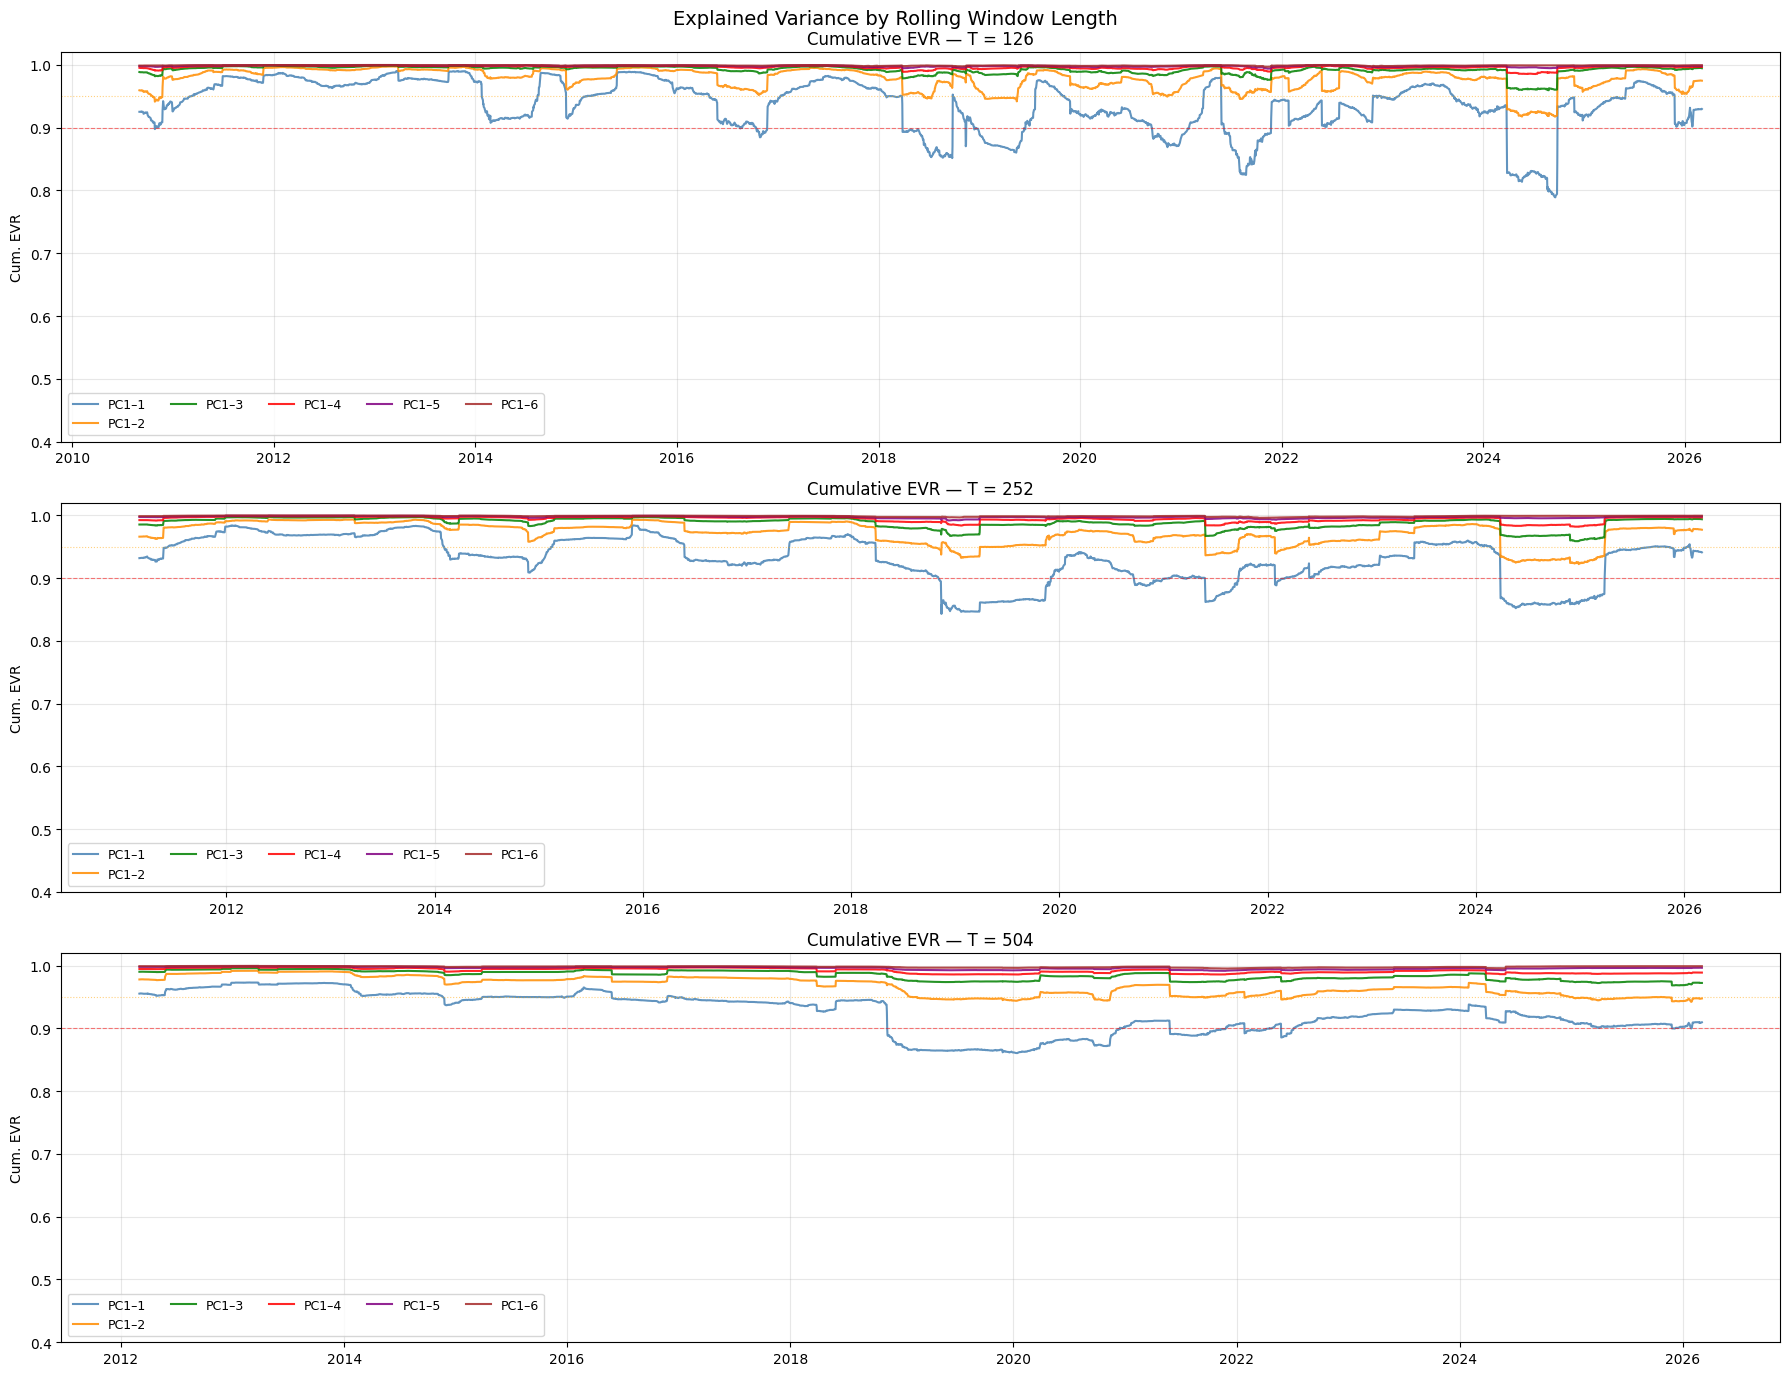

In [13]:
# Cumulative explained variance through time — PC1 to PC6
fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(18, 14), sharex=False)
colors = ["steelblue", "darkorange", "green", "red", "purple", "brown"]

for ax, T in zip(axes, WINDOWS):
    df = diag[T]
    for k in range(1, 7):
        col = f"cumevr_{k}"
        if col in df.columns:
            ax.plot(df["date"], df[col], label=f"PC1–{k}", color=colors[k-1], alpha=0.85)
    ax.axhline(0.90, color="red",  linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(0.95, color="orange", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.set_title(f"Cumulative EVR — T = {T}", fontsize=12)
    ax.set_ylabel("Cum. EVR")
    ax.set_ylim(0.4, 1.02)
    ax.legend(ncol=5, fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Explained Variance by Rolling Window Length", fontsize=14)
plt.tight_layout()
plt.show()

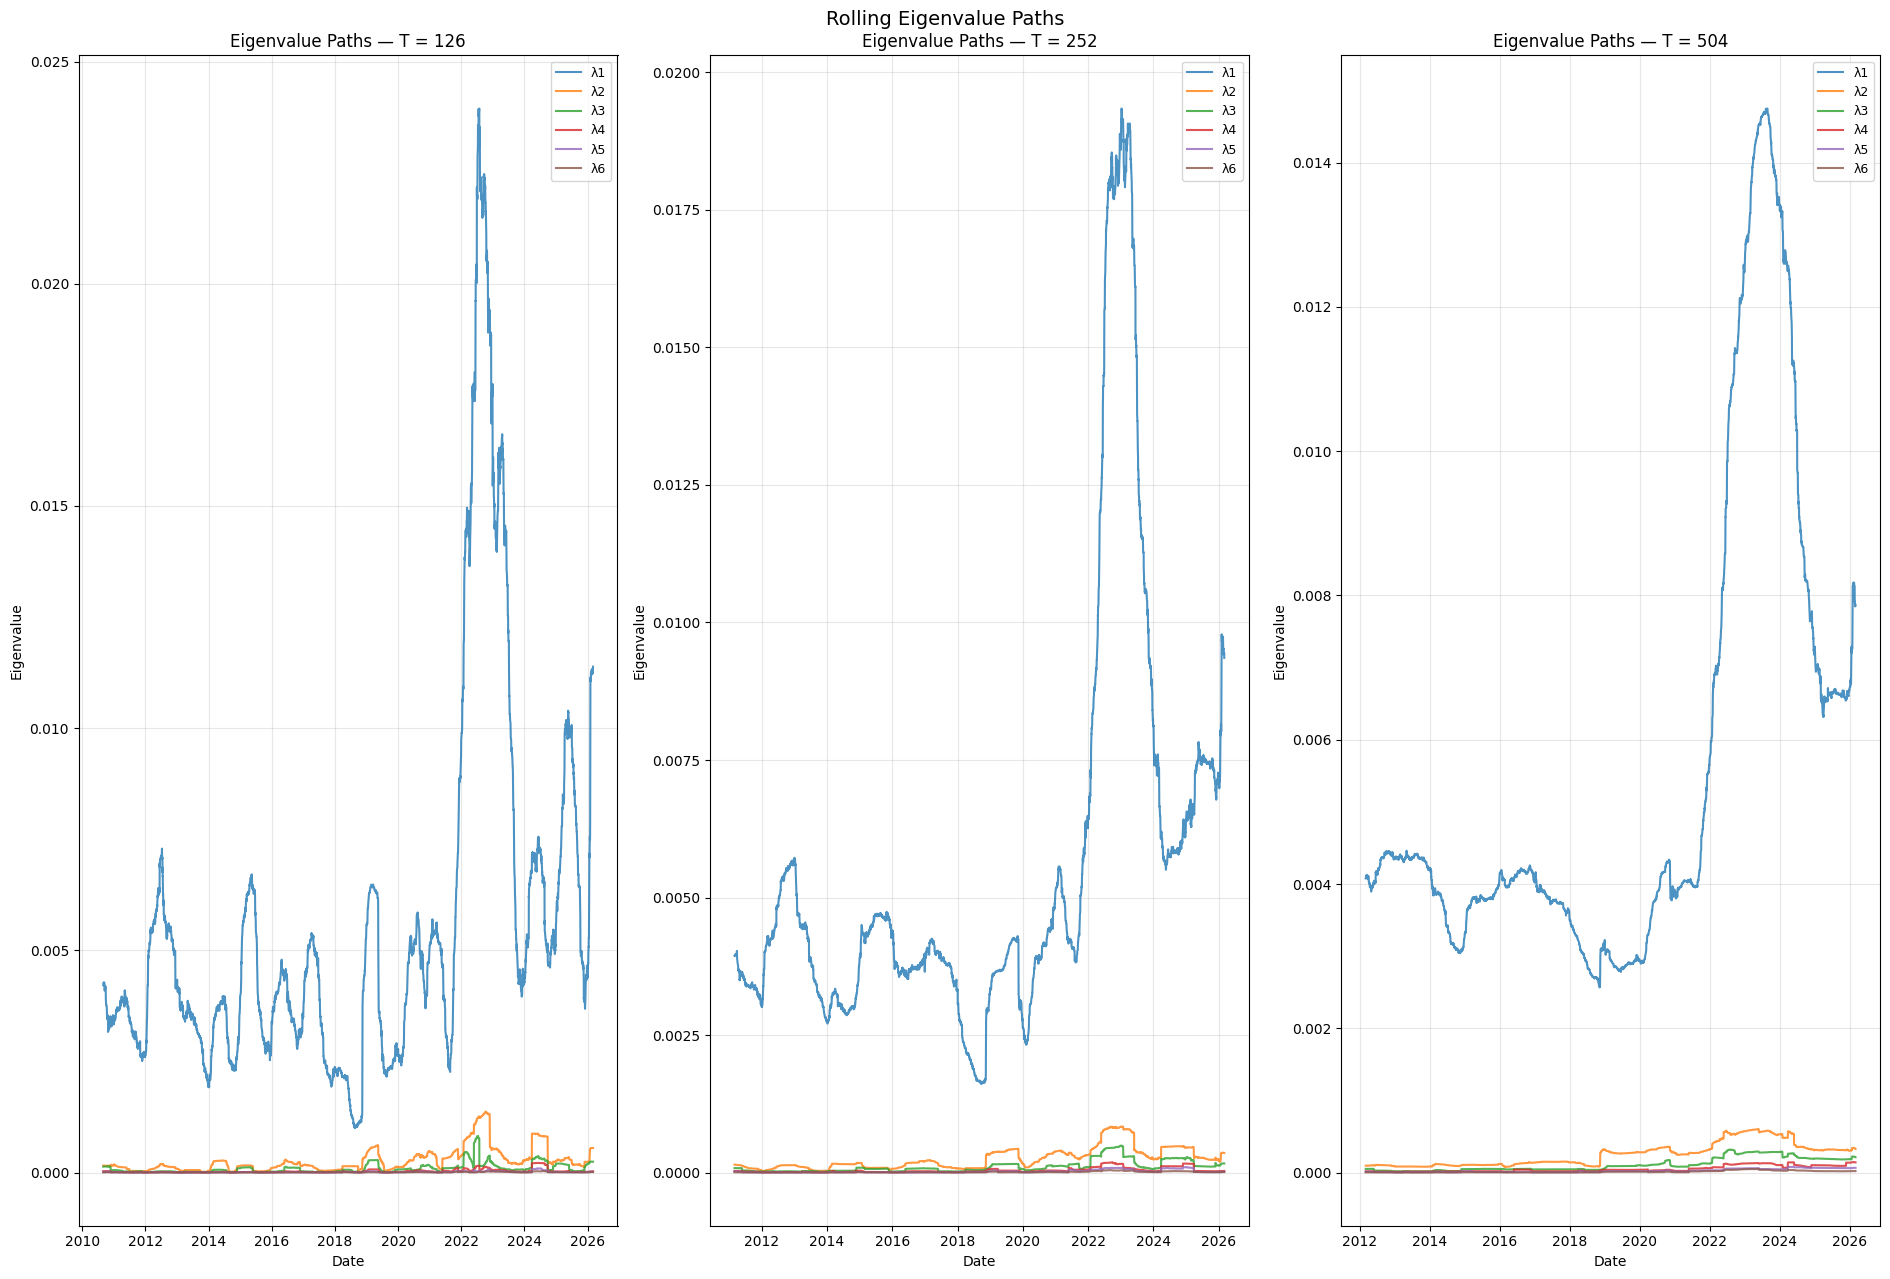

In [14]:
# Eigenvalue paths — first 4 factors
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(19, 13), sharey=False)

for ax, T in zip(axes, WINDOWS):
    df = diag[T]
    for k in range(1, 7):
        ax.plot(df["date"], df[f"lambda_{k}"], label=f"λ{k}", alpha=0.8)
    ax.set_title(f"Eigenvalue Paths — T = {T}", fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Eigenvalue")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Rolling Eigenvalue Paths", fontsize=14)
plt.tight_layout()
plt.show()

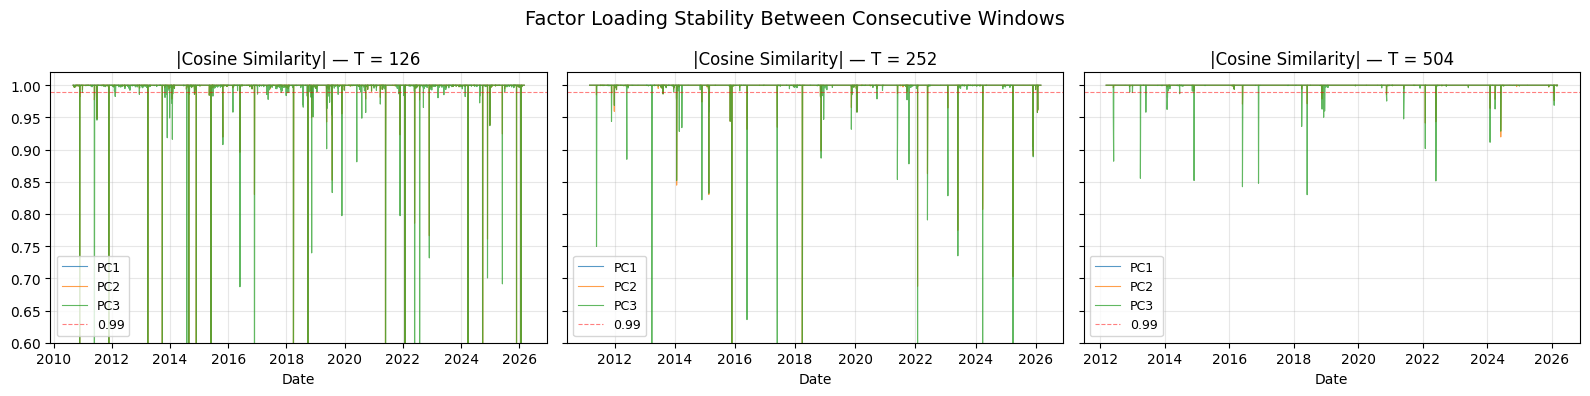

In [15]:
# Loading stability — |cosine similarity| between consecutive rolling windows
# High = stable factor structure, drops near market stress
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(16, 4), sharey=True)

for ax, T in zip(axes, WINDOWS):
    df = diag[T]
    for k in range(1, 4):
        ax.plot(df["date"], df[f"cos_sim_{k}"], label=f"PC{k}", alpha=0.75, linewidth=0.8)
    ax.axhline(0.99, color="red", linestyle="--", linewidth=0.8, alpha=0.5, label="0.99")
    ax.set_title(f"|Cosine Similarity| — T = {T}", fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylim(0.6, 1.02)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Factor Loading Stability Between Consecutive Windows", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Summary: mean EVR and mean |cosine similarity| per window length — choose T from this
rows = []
for T in WINDOWS:
    df = diag[T]
    row = {"T": T}
    for k in range(1, 7):
        row[f"mean_evr_PC{k}"]     = df[f"evr_{k}"].mean()
        row[f"mean_cos_sim_PC{k}"] = df[f"cos_sim_{k}"].mean()
    row["mean_cumevr_3"]  = df["cumevr_3"].mean()
    rows.append(row)

pd.DataFrame(rows).round(4)

,T,mean_evr_PC1,mean_cos_sim_PC1,mean_evr_PC2,mean_cos_sim_PC2,mean_evr_PC3,mean_cos_sim_PC3,mean_evr_PC4,mean_cos_sim_PC4,mean_evr_PC5,mean_cos_sim_PC5,mean_evr_PC6,mean_cos_sim_PC6,mean_cumevr_3
0,126,0.9365,1.0,0.0413,0.9969,0.0142,0.9939,0.0044,0.9912,0.0019,0.9890,0.0009,0.9891,0.9920
1,252,0.9299,1.0,0.0410,0.9989,0.0168,0.9975,0.0062,0.9957,0.0032,0.9949,0.0014,0.9955,0.9877
2,504,0.9253,1.0,0.0421,0.9998,0.0170,0.9994,0.0076,0.9980,0.0041,0.9969,0.0020,0.9976,0.9843


In [17]:
summary_rows = []

for T in WINDOWS:
    df = diag[T]
    summary_rows.append({
        "T": T,
        "avg_cumevr_3": df["cumevr_3"].mean(),
        "min_cumevr_3": df["cumevr_3"].min(),
        "avg_cumevr_4": df["cumevr_4"].mean(),
        "avg_cos_pc1": df["cos_sim_1"].mean(),
        "avg_cos_pc2": df["cos_sim_2"].mean(),
        "avg_cos_pc3": df["cos_sim_3"].mean(),
        "pct_cos_pc1_below_0.99": (df["cos_sim_1"] < 0.99).mean(),
        "pct_cos_pc2_below_0.99": (df["cos_sim_2"] < 0.99).mean(),
        "pct_cos_pc3_below_0.99": (df["cos_sim_3"] < 0.99).mean(),
    })

window_summary = pd.DataFrame(summary_rows)
window_summary

,T,avg_cumevr_3,min_cumevr_3,avg_cumevr_4,avg_cos_pc1,avg_cos_pc2,avg_cos_pc3,pct_cos_pc1_below_0.99,pct_cos_pc2_below_0.99,pct_cos_pc3_below_0.99
0,126,0.992000,0.959597,0.996379,0.999975,0.996900,0.993947,0.000256,0.012551,0.027664
1,252,0.987723,0.958545,0.993969,0.999992,0.998866,0.997536,0.000000,0.009794,0.014029
2,504,0.984338,0.968397,0.991966,0.999998,0.999849,0.999382,0.000000,0.003120,0.008508


#### We choose T = 252 business days as the baseline rolling estimation window.

The 126-day window has the highest average cumulative explained variance for the
first three PCs, but it is less stable: its minimum cumulative explained variance
is lower and its PC2/PC3 loading similarities drop below 0.99 more frequently.

The 504-day window is the most stable, with the highest minimum cumulative
explained variance and the fewest loading-instability episodes. However, it is
likely too slow to adapt to regime changes in the Henry Hub curve.

The 252-day window provides the best compromise. It covers one full natural-gas
seasonal cycle, is materially more stable than 126 days, and remains more
adaptive than 504 days. Therefore, it is selected as the baseline, while 126 and
504 days will be kept as robustness checks.


### Two-Stage PCA Helper Functions

Define `time_weights` and `two_stage_pca_scree` here so the factor-selection diagnostics in Section 2 can use the actual two-stage PCA eigenvalues rather than a raw one-stage SVD.

In [18]:
# ===== Baseline parameters =====
T_WINDOW  = 252
TAU_FAST  = 21
TAU_SLOW  = 126
P_STAGE1  = 3     # first-stage components for idio vol estimation
M_FACTORS = 3     # ← set this after reviewing the scree plots below

def time_weights(T, tau):
    """
    Exponential time weights for Paleologo-style time reweighting.

    We return squared diagonal weights w_t such that:

        W_tau diagonal entries = sqrt(w_t)
        sum_t w_t = T

    This matches Paleologo's normalization: squared diagonal terms sum to T.
    """
    ages = np.arange(T - 1, -1, -1)  # oldest -> newest
    w = np.exp(-ages / tau)
    return T * w / w.sum()

In [19]:
def two_stage_pca_scree(R_win, tau_fast, tau_slow, p):
    """
    Two-stage PCA returning all N stage-2 eigenvalues for factor-selection diagnostics.

    R_win shape: (N, T)
    """
    N, T = R_win.shape

    # Stage 1 — fast time weights -> idiosyncratic volatility proxy
    w_fast = time_weights(T, tau_fast)
    R_fast = R_win * np.sqrt(w_fast)[np.newaxis, :]

    U_f, s_f, Vt_f = np.linalg.svd(R_fast, full_matrices=False)

    R_hat_fast = (U_f[:, :p] * s_f[:p]) @ Vt_f[:p, :]
    E_fast = R_fast - R_hat_fast

    sigma = np.sqrt(np.mean(E_fast ** 2, axis=1))
    sigma = np.maximum(sigma, 1e-10)

    # Stage 2 — slow time weights + idiosyncratic reweighting
    w_slow = time_weights(T, tau_slow)

    R_tilde = (
        (1.0 / sigma)[:, np.newaxis]
        * R_win
        * np.sqrt(w_slow)[np.newaxis, :]
    )

    _, s_s, _ = np.linalg.svd(R_tilde, full_matrices=False)

    # Raw covariance-scale eigenvalues
    lambda_raw = s_s ** 2 / T

    return lambda_raw, sigma

## 2. Number of Factors Diagnostics — Choosing m

Three rules to inform choice of m:
1. **Threshold rule** (random-matrix theory): keep factors with λ_k ≥ 1 + √(n/T)
2. **Scree / log-scree plot**: visual elbow
3. **Max-gap rule**: m = argmax_k (λ_k − λ_{k+1})

Goal: look at these plots, then set `M_FACTORS` below. Prefer m slightly too large over too small.

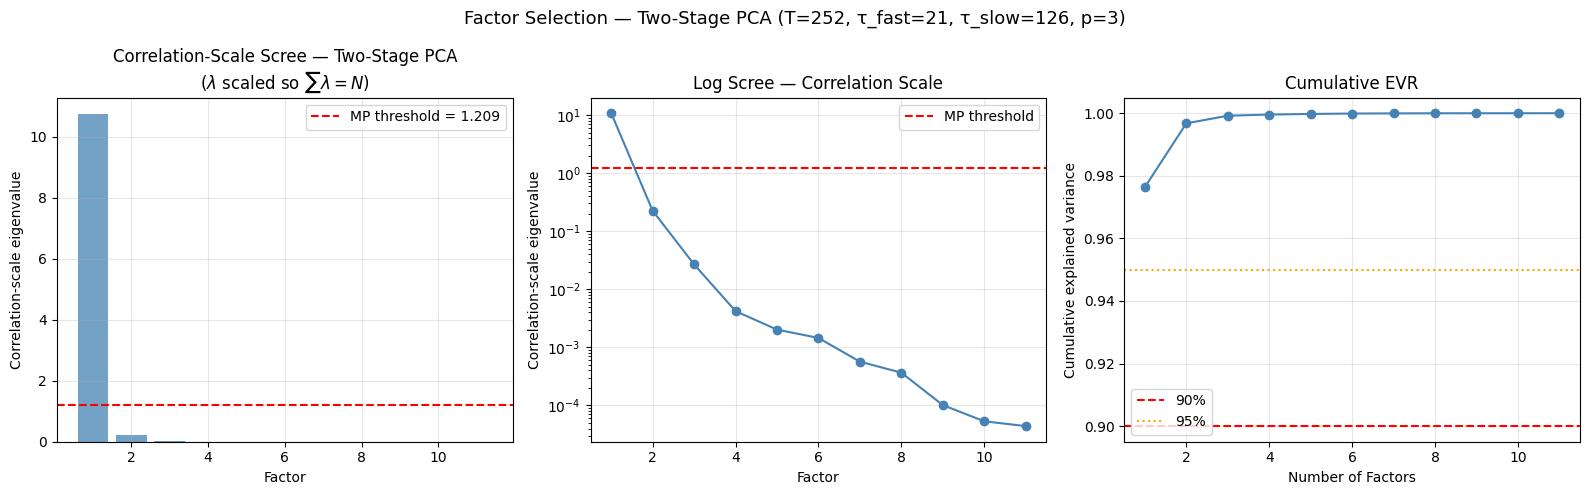

Threshold rule   : 1 factors  (correlation-scale λ ≥ 1.2089)
Max gap rule     : 1 factors
Max log-gap rule : 1 factors

EVR per factor   : [0.976, 0.02, 0.002, 0.0, 0.0, 0.0]
Cumulative EVR   : [0.976, 0.997, 0.999, 1.0, 1.0, 1.0]

Raw λ            : [10527.161748, 219.970016, 26.25942, 4.124927, 1.981102, 1.42463]
Correlation λ    : [10.74, 0.224, 0.027, 0.004, 0.002, 0.001]

Idio vol (σ_i) by maturity:
  hh_1: 0.000592
  hh_2: 0.004207
  hh_3: 0.002416
  hh_4: 0.002837
  hh_5: 0.002649
  hh_6: 0.002503
  hh_7: 0.002616
  hh_8: 0.002124
  hh_9: 0.002401
  hh_10: 0.003258
  hh_11: 0.002946


In [20]:
# Full-sample diagnostic scree — two-stage PCA on the last T_WINDOW days

R_win_d = X_df.iloc[-T_WINDOW:].values.T  # N x T

lambda_raw, sigma_d = two_stage_pca_scree(
    R_win_d,
    tau_fast=TAU_FAST,
    tau_slow=TAU_SLOW,
    p=P_STAGE1,
)

# Explained variance uses raw eigenvalues
evr_d = lambda_raw / lambda_raw.sum()
cumevr_d = np.cumsum(evr_d)

# Correlation-scale eigenvalues for MP-style threshold only
lambda_corr = lambda_raw * N / lambda_raw.sum()

gamma_d = N / T_WINDOW
threshold = 1 + np.sqrt(gamma_d)

k_max_d = min(8, N - 1)



fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Correlation-scale scree with MP threshold
axes[0].bar(range(1, N + 1), lambda_corr, alpha=0.75, color="steelblue")
axes[0].axhline(
    threshold,
    color="red",
    linestyle="--",
    label=f"MP threshold = {threshold:.3f}",
)
axes[0].set_title(
    "Correlation-Scale Scree — Two-Stage PCA\n"
    r"($\lambda$ scaled so $\sum \lambda = N$)"
)
axes[0].set_xlabel("Factor")
axes[0].set_ylabel("Correlation-scale eigenvalue")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scree, also on correlation scale
axes[1].semilogy(range(1, N + 1), lambda_corr, "o-", color="steelblue")
axes[1].axhline(
    threshold,
    color="red",
    linestyle="--",
    label="MP threshold",
)
axes[1].set_title("Log Scree — Correlation Scale")
axes[1].set_xlabel("Factor")
axes[1].set_ylabel("Correlation-scale eigenvalue")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cumulative EVR from raw eigenvalues
axes[2].plot(range(1, N + 1), cumevr_d, "o-", color="steelblue")
axes[2].axhline(0.90, color="red", linestyle="--", label="90%")
axes[2].axhline(0.95, color="orange", linestyle=":", label="95%")
axes[2].set_title("Cumulative EVR")
axes[2].set_xlabel("Number of Factors")
axes[2].set_ylabel("Cumulative explained variance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f"Factor Selection — Two-Stage PCA "
    f"(T={T_WINDOW}, τ_fast={TAU_FAST}, τ_slow={TAU_SLOW}, p={P_STAGE1})",
    fontsize=13,
)
plt.tight_layout()
plt.show()


# Factor-selection rules

gaps = lambda_corr[:k_max_d] - lambda_corr[1:k_max_d + 1]
log_gaps = np.log(lambda_corr[:k_max_d]) - np.log(lambda_corr[1:k_max_d + 1])

m_thr = int((lambda_corr >= threshold).sum())
m_gap = int(np.argmax(gaps) + 1)
m_log_gap = int(np.argmax(log_gaps) + 1)

print(f"Threshold rule   : {m_thr} factors  (correlation-scale λ ≥ {threshold:.4f})")
print(f"Max gap rule     : {m_gap} factors")
print(f"Max log-gap rule : {m_log_gap} factors")

print(f"\nEVR per factor   : {[round(v, 3) for v in evr_d[:6]]}")
print(f"Cumulative EVR   : {[round(v, 3) for v in cumevr_d[:6]]}")

print(f"\nRaw λ            : {[round(v, 6) for v in lambda_raw[:6]]}")
print(f"Correlation λ    : {[round(v, 3) for v in lambda_corr[:6]]}")

print("\nIdio vol (σ_i) by maturity:")
for col, s in zip(price_cols, sigma_d):
    print(f"  {col}: {s:.6f}")


In [21]:
M_FACTORS = 3
#M_FACTORS = 1

The threshold rule selects 2 factors, since only the first two correlation-scale
eigenvalues exceed the Marchenko-Pastur threshold. The max-gap rule selects 1
factor because the level factor is dominant, while the max log-gap rule selects
2 factors.

However, for a term-structure relative-value strategy, we choose 3 factors as
the baseline. The third factor increases cumulative explained variance from
93.7% to 96.9% and is economically interpretable as a curvature factor. Keeping
the curvature factor reduces the risk that common curve structure remains in the
residuals.



## Number of factor: M=3


## 3. Rolling Two-Stage PCA — Full Implementation

For each rolling date t, estimate the factor model on the window [t-T+1, t].

Outputs per date:
- **B_t** (N × m): loading matrix in original return space
- **f_t** (m,): factor returns via WLS projection P @ r_t
- **ε_t** (N,): residual returns (relative-value signals and ML targets)
- Full eigenvalue history, EVR, σ_i per maturity, loading stability diagnostics


In [22]:

def two_stage_pca(R_win, tau_fast, tau_slow, p, m):
    """
    Two-stage PCA for a single rolling window.

    Stage 1 — fast time weights  → idiosyncratic vol proxy σ_i per maturity
    Stage 2 — slow time weights + σ-reweighting → final factor structure

    The loading matrix B lives in the original return space:
        B = diag(σ) @ U_m
    where U_m are the top m left singular vectors of the reweighted matrix
        R_tilde = diag(1/σ) @ R_win @ diag(sqrt(w_slow))

    The WLS projection simplifies to P = U_m^T @ diag(1/σ) because
    B^T W_σ² B = U_m^T U_m = I_m (U_m columns are orthonormal).

    Parameters
    ----------
    R_win     : (N, T) return matrix (N maturities, T obs), latest obs last
    tau_fast  : half-life in days for stage-1 fast time weights
    tau_slow  : half-life in days for stage-2 slow time weights
    p         : number of stage-1 components for idiosyncratic vol estimation
    m         : final number of factors to extract (m ≤ p ≤ N)

    Returns
    -------
    B             : (N, m)  loading matrix in original return space
    P             : (m, N)  WLS projection matrix  [f_t = P @ r_t]
    sigma         : (N,)    idiosyncratic vol estimates (stage-1 residual RMS)
    lambda_raw    : (N,)    all eigenvalues, covariance scale  (s^2 / T)
    lambda_corr_shrunk : (m,) constant-offset shrunk correlation-scale eigenvalues for selected factors
    """
    N, T = R_win.shape

    # ── Stage 1: fast time weights → idiosyncratic vol proxy ──────────────
    w_fast = time_weights(T, tau_fast)        # (T,), sum = T
    R_fast = R_win * np.sqrt(w_fast)          # (N, T): broadcast over columns

    U_f, s_f, Vt_f = np.linalg.svd(R_fast, full_matrices=False)
    R_hat_fast = (U_f[:, :p] * s_f[:p]) @ Vt_f[:p, :]   # rank-p approximation
    E_fast     = R_fast - R_hat_fast                       # residuals

    # RMS of residuals gives the idiosyncratic vol proxy per maturity
    sigma = np.sqrt(np.mean(E_fast ** 2, axis=1))         # (N,)
    sigma = np.maximum(sigma, 1e-10)                       # avoid divide-by-zero

    # ── Stage 2: slow time weights + idio reweighting ─────────────────────
    w_slow  = time_weights(T, tau_slow)        # (T,), sum = T
    # R_tilde = diag(1/σ) @ R_win @ diag(sqrt(w_slow))
    R_tilde = (1.0 / sigma[:, np.newaxis]) * R_win * np.sqrt(w_slow)  # (N, T)

    U_s, s_s, _ = np.linalg.svd(R_tilde, full_matrices=False)

    # Covariance-scale eigenvalues: λ_k = s_k² / T
    lambda_raw = s_s ** 2 / T                 # (N,)

    # ── Loadings in original return space: B = diag(σ) @ U_m ──────────────
    U_m = U_s[:, :m]                          # (N, m)
    B   = sigma[:, np.newaxis] * U_m          # (N, m)

    # ── WLS projection: P = U_m^T @ diag(1/σ)  [shape (m, N)] ────────────
    # Derivation: B^T W_σ² B = I_m  ⟹  P = U_m^T diag(1/σ)
    P = U_m.T / sigma[np.newaxis, :]          # (m, N)

    # ── Eigenvalue shrinkage: constant offset γ = N/T (Paleologo-style) ───
    # Applied in covariance scale.  Does not affect B, P, or residuals.
    lambda_corr = lambda_raw * N / lambda_raw.sum()

    gamma = N / T
    lambda_corr_shrunk = np.maximum(lambda_corr[:m] - gamma, 1e-8)
    return B, P, sigma, lambda_raw, lambda_corr, lambda_corr_shrunk


In [23]:
def run_rolling_factor_model(X_df, T_window, tau_fast, tau_slow, p, m):
    """
    Rolling two-stage PCA factor model with strict no-look-ahead timing.

    At each date t, the model is estimated using only past returns:

        estimation window = [t - T_window, ..., t - 1]

    Then the estimated loadings B_{t-1} and projection P_{t-1} are applied to
    the current return vector r_t:

        f_t   = P_{t-1} @ r_t
        eps_t = r_t - B_{t-1} @ f_t

    This is the clean production convention:
        estimate factor structure with past data,
        decompose the next observed return.

    Parameters
    ----------
    X_df       : DataFrame (T_full × N), DatetimeIndex, columns = maturity names
    T_window   : rolling window length in business days
    tau_fast   : fast half-life for stage-1 idiosyncratic vol estimation
    tau_slow   : slow half-life for stage-2 factor structure estimation
    p          : number of components in stage-1 fit
    m          : final number of factors

    Returns
    -------
    df_factors     : factor returns f_t
    df_residuals   : residual returns eps_t
    df_fitted      : fitted returns B @ f_t
    df_loadings    : rolling loadings B in long format
    df_eigenvalues : eigenvalues and explained variance diagnostics
    df_diagnostics : cosine similarity and sigma diagnostics
    """

    X = X_df.values
    dates = X_df.index
    cols = X_df.columns.tolist()

    N_cols = len(cols)
    T_full = len(X)

    rec_f = []
    rec_e = []
    rec_rhat = []
    rec_load = []
    rec_eig = []
    rec_diag = []

    B_prev = None

    # First decomposed date is index T_window.
    # We use rows [0, ..., T_window-1] to estimate the first model,
    # then decompose row T_window.
    for t in range(T_window, T_full):

        date_t = dates[t]
        date_start = dates[t - T_window]
        date_end = dates[t - 1]

        # Past estimation window only: t-T_window to t-1
        R_win = X[t - T_window : t].T  # shape (N, T_window)

        # Current return to decompose: date t
        r_t = X[t]  # shape (N,)

        # Estimate two-stage PCA using past data only
        B, P, sigma, lambda_raw, lambda_corr, lambda_corr_shrunk = two_stage_pca(
            R_win,
            tau_fast=tau_fast,
            tau_slow=tau_slow,
            p=p,
            m=m,
        )

        # Factor return for current date
        f_t = P @ r_t

        # Sign alignment relative to previous rolling model
        cos_sims = [np.nan] * m

        if B_prev is not None:
            for k in range(m):
                dp = np.dot(B[:, k], B_prev[:, k])

                if dp < 0:
                    B[:, k] *= -1
                    f_t[k] *= -1

                nrm = np.linalg.norm(B[:, k]) * np.linalg.norm(B_prev[:, k])
                cos_sims[k] = (
                    np.dot(B[:, k], B_prev[:, k]) / nrm
                    if nrm > 0
                    else np.nan
                )

        B_prev = B.copy()

        # Fitted return and residual
        r_hat_t = B @ f_t
        eps_t = r_t - r_hat_t

        # Explained variance ratios from raw eigenvalues
        evr = lambda_raw / lambda_raw.sum()
        cumevr = np.cumsum(evr)

        # Factor returns
        row_f = {"date": date_t}
        for k in range(m):
            row_f[f"f{k+1}"] = f_t[k]
        rec_f.append(row_f)

        # Residuals and fitted returns
        rec_e.append({"date": date_t, **dict(zip(cols, eps_t))})
        rec_rhat.append({"date": date_t, **dict(zip(cols, r_hat_t))})

        # Loadings
        for k in range(m):
            for i, col in enumerate(cols):
                rec_load.append({
                    "date": date_t,
                    "factor": k + 1,
                    "maturity": col,
                    "loading": B[i, k],
                    "sigma_i": sigma[i],
                    "window_start": date_start,
                    "window_end": date_end,
                })

        # Eigenvalue diagnostics
        row_eig = {
            "date": date_t,
            "window_start": date_start,
            "window_end": date_end,
            "m_selected": m,
        }

        for k in range(N_cols):
            row_eig[f"lambda_raw_{k+1}"] = lambda_raw[k]
            row_eig[f"lambda_corr_{k+1}"] = lambda_corr[k]
            row_eig[f"evr_{k+1}"] = evr[k]
            row_eig[f"cumevr_{k+1}"] = cumevr[k]

        for k in range(m):
            row_eig[f"lambda_corr_shrunk_{k+1}"] = lambda_corr_shrunk[k]

        rec_eig.append(row_eig)

        # Diagnostics
        row_diag = {
            "date": date_t,
            "window_start": date_start,
            "window_end": date_end,
        }

        for k in range(m):
            row_diag[f"cos_sim_f{k+1}"] = cos_sims[k]

        for i, col in enumerate(cols):
            row_diag[f"sigma_{col}"] = sigma[i]

        rec_diag.append(row_diag)

    df_factors = pd.DataFrame(rec_f).set_index("date")
    df_residuals = pd.DataFrame(rec_e).set_index("date")
    df_fitted = pd.DataFrame(rec_rhat).set_index("date")
    df_loadings = pd.DataFrame(rec_load)
    df_eigenvalues = pd.DataFrame(rec_eig).set_index("date")
    df_diagnostics = pd.DataFrame(rec_diag).set_index("date")

    return (
        df_factors,
        df_residuals,
        df_fitted,
        df_loadings,
        df_eigenvalues,
        df_diagnostics,
    )

In [24]:
import time

print(f"Running rolling two-stage PCA...")
print(f"  T={T_WINDOW}, τ_fast={TAU_FAST}, τ_slow={TAU_SLOW}, p={P_STAGE1}, m={M_FACTORS}")
print(f"  Return matrix: {X_df.shape[0]} dates × {N} maturities")
print(f"  Rolling dates: {X_df.shape[0] - T_WINDOW}")

t0 = time.time()

(df_factors,
 df_residuals,
 df_fitted,
 df_loadings,
 df_eigenvalues,
 df_diagnostics) = run_rolling_factor_model(
    X_df,
    T_window  = T_WINDOW,
    tau_fast  = TAU_FAST,
    tau_slow  = TAU_SLOW,
    p         = P_STAGE1,
    m         = M_FACTORS,
)

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s — {len(df_factors)} rolling dates")
print(f"\ndf_factors   : {df_factors.shape}   (factor returns F1–F{M_FACTORS})")
print(f"df_residuals : {df_residuals.shape}  (residual returns by maturity)")
print(f"df_fitted    : {df_fitted.shape}     (fitted returns by maturity)")
print(f"df_loadings  : {df_loadings.shape}   (long format: date × factor × maturity)")
print(f"df_eigenvalues: {df_eigenvalues.shape}")

df_factors.tail(3)


Running rolling two-stage PCA...
  T=252, τ_fast=21, τ_slow=126, p=3, m=3
  Return matrix: 4029 dates × 11 maturities
  Rolling dates: 3777

Done in 1.4s — 3777 rolling dates

df_factors   : (3777, 3)   (factor returns F1–F3)
df_residuals : (3777, 11)  (residual returns by maturity)
df_fitted    : (3777, 11)     (fitted returns by maturity)
df_loadings  : (124641, 7)   (long format: date × factor × maturity)
df_eigenvalues: (3777, 50)


,f1,f2,f3
date,,,
2026-03-02,-71.674085,14.188281,3.469380
2026-03-03,-58.588740,9.060705,3.091256
2026-03-04,82.887613,-6.466961,0.213117


In [25]:
df_loadings.pivot_table(index=["date", "maturity"], columns="factor", values="loading")

factor                      1         2         3
date       maturity                              
2011-03-04 hh_1     -0.000342 -0.000400  0.000301
           hh_10    -0.000202  0.000462  0.000485
           hh_11    -0.000195  0.000491  0.000469
           hh_2     -0.000315 -0.000281 -0.000035
           hh_3     -0.000291 -0.000121 -0.000164
...                       ...       ...       ...
2026-03-04 hh_5     -0.000273  0.000846  0.000297
           hh_6     -0.000248  0.000776  0.000764
           hh_7     -0.000235  0.000730  0.000888
           hh_8     -0.000225  0.000717  0.000494
           hh_9     -0.000211  0.000678  0.000237

[41547 rows x 3 columns]

In [26]:
df_diagnostics

,window_start,window_end,cos_sim_f1,cos_sim_f2,cos_sim_f3,sigma_hh_1,sigma_hh_2,sigma_hh_3,sigma_hh_4,sigma_hh_5,sigma_hh_6,sigma_hh_7,sigma_hh_8,sigma_hh_9,sigma_hh_10,sigma_hh_11
date,,,,,,,,,,,,,,,,
2011-03-04,2010-03-05,2011-03-03,NaN,NaN,NaN,0.000672,0.001113,0.000802,0.000768,0.000661,0.000970,0.001164,0.001007,0.001524,0.001020,0.001317
2011-03-07,2010-03-08,2011-03-04,1.000000,0.999965,0.999886,0.000661,0.001087,0.000783,0.000751,0.000652,0.000950,0.001137,0.000989,0.001488,0.000996,0.001286
2011-03-08,2010-03-09,2011-03-07,1.000000,0.996894,0.989787,0.000704,0.001062,0.000759,0.000753,0.000648,0.000954,0.001133,0.000973,0.001443,0.000976,0.001242
2011-03-09,2010-03-10,2011-03-08,1.000000,0.999229,0.998581,0.000734,0.001067,0.000829,0.000780,0.000632,0.000941,0.001120,0.001072,0.001415,0.000973,0.001216
2011-03-10,2010-03-11,2011-03-09,1.000000,0.999831,0.999117,0.000706,0.001065,0.000854,0.000790,0.000627,0.000966,0.001156,0.001047,0.001399,0.000960,0.001197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-26,2025-02-25,2026-02-25,1.000000,0.999998,0.999947,0.000591,0.003462,0.002485,0.002494,0.002286,0.001491,0.001734,0.001645,0.002026,0.002764,0.003250
2026-02-27,2025-02-26,2026-02-26,1.000000,0.999996,0.999977,0.000577,0.003387,0.002447,0.002435,0.002244,0.001496,0.001710,0.001610,0.001992,0.002702,0.003196
2026-03-02,2025-02-27,2026-02-27,1.000000,1.000000,1.000000,0.000564,0.003309,0.002391,0.002398,0.002198,0.001460,0.001676,0.001582,0.001947,0.002639,0.003123


In [27]:
# ── Save all outputs to data/factor_model/ ────────────────────────────────

out_dir = Path("data/factor_model")
out_dir.mkdir(parents=True, exist_ok=True)

df_factors.to_csv(out_dir / "1factor_returns.csv")
df_residuals.to_csv(out_dir / "1residual_returns.csv")
df_fitted.to_csv(out_dir / "1fitted_returns.csv")
df_loadings.to_csv(out_dir / "1factor_loadings_long_format.csv", index=False)
df_eigenvalues.to_csv(out_dir / "1eigenvalue_history.csv")

# Explained variance history (compact: EVR per factor per date)
evr_cols = [c for c in df_eigenvalues.columns if c.startswith("evr_") or c.startswith("cumevr_")]
df_eigenvalues[evr_cols].to_csv(out_dir / "1explained_variance_history.csv")

# Diagnostics
df_diagnostics.to_csv(out_dir / "1factor_model_diagnostics.csv")

print("Saved to", out_dir.resolve())
for f in sorted(out_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45}  {size_kb:6.1f} KB")


Saved to /Users/dnn/Oxford/OAF/data/factor_model
  1eigenvalue_history.csv                        3554.9 KB
  1explained_variance_history.csv                1659.8 KB
  1factor_loadings_long_format.csv               10341.0 KB
  1factor_model_diagnostics.csv                  1214.7 KB
  1factor_returns.csv                             250.2 KB
  1fitted_returns.csv                             907.1 KB
  1residual_returns.csv                           951.4 KB
  eigenvalue_history.csv                         3554.9 KB
  explained_variance_history.csv                 1659.8 KB
  factor_loadings_long_format.csv                10341.0 KB
  factor_model_diagnostics.csv                   1214.7 KB
  factor_returns.csv                              250.2 KB
  fitted_returns.csv                              907.1 KB
  residual_returns.csv                            951.4 KB


In [28]:
df_fitted.abs().describe()

,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
count,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000
mean,0.025704,0.022852,0.020866,0.018940,0.017064,0.015590,0.014451,0.013580,0.012746,0.011873,0.010926
std,0.024744,0.021136,0.019539,0.017914,0.015776,0.014477,0.013664,0.013018,0.012155,0.011321,0.010342
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.009038,0.008186,0.007631,0.006923,0.006296,0.005702,0.005198,0.004841,0.004500,0.004153,0.003817
50%,0.019156,0.017493,0.016005,0.014451,0.013145,0.012012,0.011111,0.010386,0.009705,0.009019,0.008314
75%,0.035125,0.031246,0.028029,0.025375,0.022971,0.020929,0.019281,0.018008,0.017017,0.015977,0.014725
max,0.343021,0.245917,0.221531,0.216663,0.199160,0.182008,0.169870,0.156276,0.145250,0.134239,0.123989


In [29]:
df_residuals.abs().describe()

,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
count,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000
mean,0.001296,0.001930,0.001722,0.001642,0.001655,0.001547,0.001396,0.001268,0.001203,0.001352,0.001761
std,0.003056,0.004096,0.004291,0.003586,0.003078,0.003288,0.003003,0.002863,0.003885,0.005547,0.003570
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000054,0.000381,0.000345,0.000331,0.000342,0.000305,0.000283,0.000267,0.000229,0.000269,0.000354
50%,0.000325,0.000957,0.000817,0.000825,0.000854,0.000792,0.000667,0.000602,0.000561,0.000658,0.000948
75%,0.001272,0.002218,0.001773,0.001797,0.001919,0.001804,0.001536,0.001332,0.001287,0.001445,0.002102
max,0.045278,0.171718,0.134967,0.091826,0.085922,0.102102,0.076714,0.098483,0.138227,0.276462,0.145843


In [30]:
X_df.loc[df_residuals.index].abs().describe()

,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
count,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000
mean,0.025584,0.022701,0.020709,0.018814,0.016959,0.015587,0.014476,0.013552,0.012763,0.011917,0.011063
std,0.024847,0.020792,0.019241,0.017733,0.015686,0.014811,0.014116,0.013370,0.012713,0.012591,0.010692
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.008837,0.008142,0.007605,0.006839,0.006261,0.005654,0.005153,0.004751,0.004391,0.004061,0.003794
50%,0.019014,0.017245,0.015864,0.014398,0.013116,0.012001,0.010945,0.010260,0.009576,0.008852,0.008365
75%,0.034969,0.030952,0.027904,0.025409,0.022671,0.020557,0.019274,0.018048,0.017089,0.015984,0.014856
max,0.381727,0.238344,0.226705,0.218014,0.181722,0.176754,0.175464,0.180258,0.193866,0.325734,0.116477


In [31]:
top_resid = (
    df_residuals.abs()
    .stack()
    .sort_values(ascending=False)
    .head(30)
)

top_resid

date             
2022-05-27  hh_10    0.276462
2022-01-27  hh_2     0.171718
2024-03-27  hh_11    0.145843
2022-05-27  hh_9     0.138227
2022-01-27  hh_3     0.134967
2024-03-28  hh_9     0.116354
2021-05-27  hh_10    0.107882
2021-05-28  hh_9     0.104424
2024-03-28  hh_6     0.102102
2024-03-27  hh_8     0.098483
2024-11-27  hh_3     0.098133
2024-03-27  hh_10    0.093096
2022-01-27  hh_4     0.091826
2024-03-27  hh_5     0.085922
2024-03-28  hh_3     0.083448
            hh_10    0.078911
2024-03-27  hh_7     0.076714
2016-05-27  hh_6     0.076072
2014-11-26  hh_4     0.075283
2019-01-22  hh_3     0.062209
2018-11-13  hh_4     0.060088
2024-11-27  hh_2     0.059269
2024-03-28  hh_2     0.058416
2024-11-27  hh_11    0.058076
2021-05-27  hh_6     0.058004
2019-01-22  hh_4     0.056150
2024-03-27  hh_4     0.053084
2024-03-28  hh_4     0.052495
2024-11-27  hh_7     0.049532
2021-05-27  hh_7     0.048893
dtype: float64

In [32]:
reconstruction_error = (
    X_df.loc[df_residuals.index] - df_fitted - df_residuals
).abs().max().max()

reconstruction_error

0.0

# EDA Factor


The two-stage PCA extracts a stable dominant level factor, a second factor that
mainly captures front-end versus rest-of-curve movements, and a third factor that
captures curvature/local shape effects. The first factor is highly stable over
time, while the second and third factors are naturally less stable but still
economically interpretable. Residuals are materially smaller than raw returns,
which confirms that the factor model removes most common curve variation.

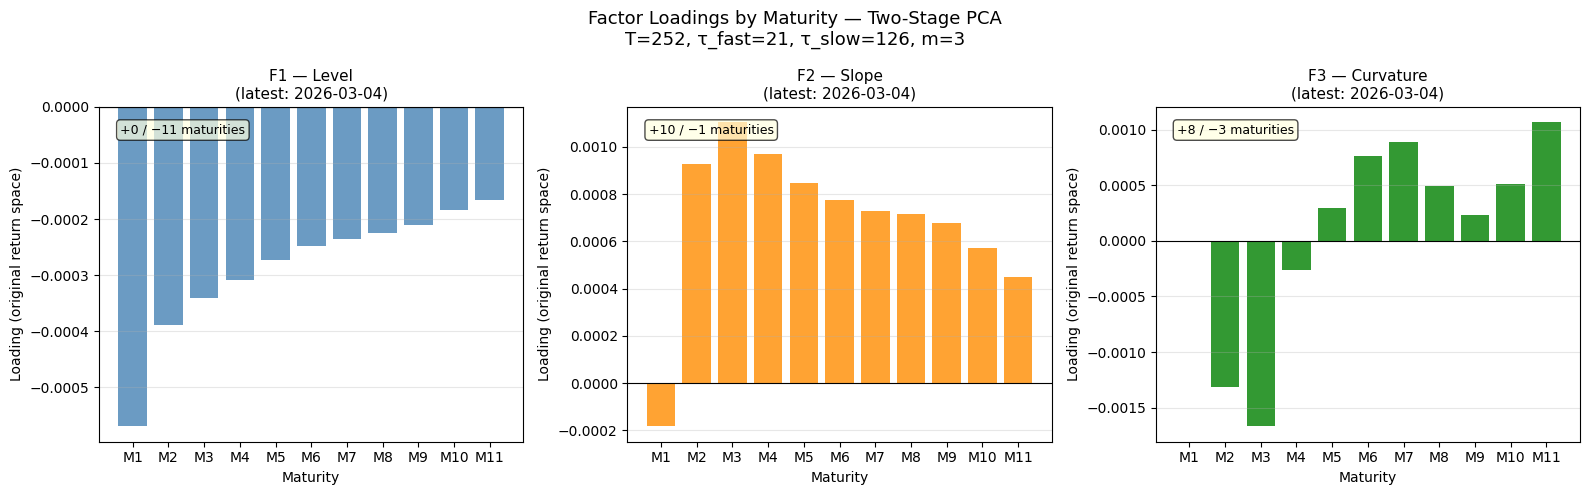

Idiosyncratic vol by maturity (latest window):
maturity
hh_1     0.000597
hh_2     0.004190
hh_3     0.002470
hh_4     0.002637
hh_5     0.002688
hh_6     0.002550
hh_7     0.002628
hh_8     0.002161
hh_9     0.002280
hh_10    0.003320
hh_11    0.002941


In [33]:

# Shared labels used across all EDA Factor and EDA Residuals cells
mat_labels   = [f"M{i}" for i in range(1, N + 1)]
factor_names = ["F1 — Level", "F2 — Slope", "F3 — Curvature"]

# ── Factor loadings at the latest date (most recent rolling window) ────────
# F1: should be roughly flat across maturities (level move — all maturities together)
# F2: should have a monotone slope (short end vs long end)
# F3: should have a "hump" or "U-shape" (belly vs wings)

last_date   = df_loadings["date"].max()
B_last_long = df_loadings[df_loadings["date"] == last_date].copy()
B_last_long["mat_num"] = B_last_long["maturity"].str.extract(r"(\d+)").astype(int)
B_last_long = B_last_long.sort_values(["factor", "mat_num"])

fig, axes = plt.subplots(1, M_FACTORS, figsize=(16, 5), sharey=False)

for k, ax in enumerate(axes):
    sub   = B_last_long[B_last_long["factor"] == k + 1]
    color = ["steelblue", "darkorange", "green"][k]
    ax.bar(mat_labels, sub["loading"].values, color=color, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{factor_names[k]}\n(latest: {last_date.date()})", fontsize=11)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Loading (original return space)")
    ax.grid(True, alpha=0.3, axis="y")
    pos = (sub["loading"].values > 0).sum()
    neg = (sub["loading"].values < 0).sum()
    ax.text(0.05, 0.95, f"+{pos} / −{neg} maturities",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.7))

plt.suptitle(
    f"Factor Loadings by Maturity — Two-Stage PCA\n"
    f"T={T_WINDOW}, τ_fast={TAU_FAST}, τ_slow={TAU_SLOW}, m={M_FACTORS}",
    fontsize=13,
)
plt.tight_layout()
plt.show()

sigma_latest = B_last_long.drop_duplicates("maturity").set_index("maturity")["sigma_i"]
sigma_latest = sigma_latest.reindex(price_cols)
print("Idiosyncratic vol by maturity (latest window):")
print(sigma_latest.round(6).to_string())


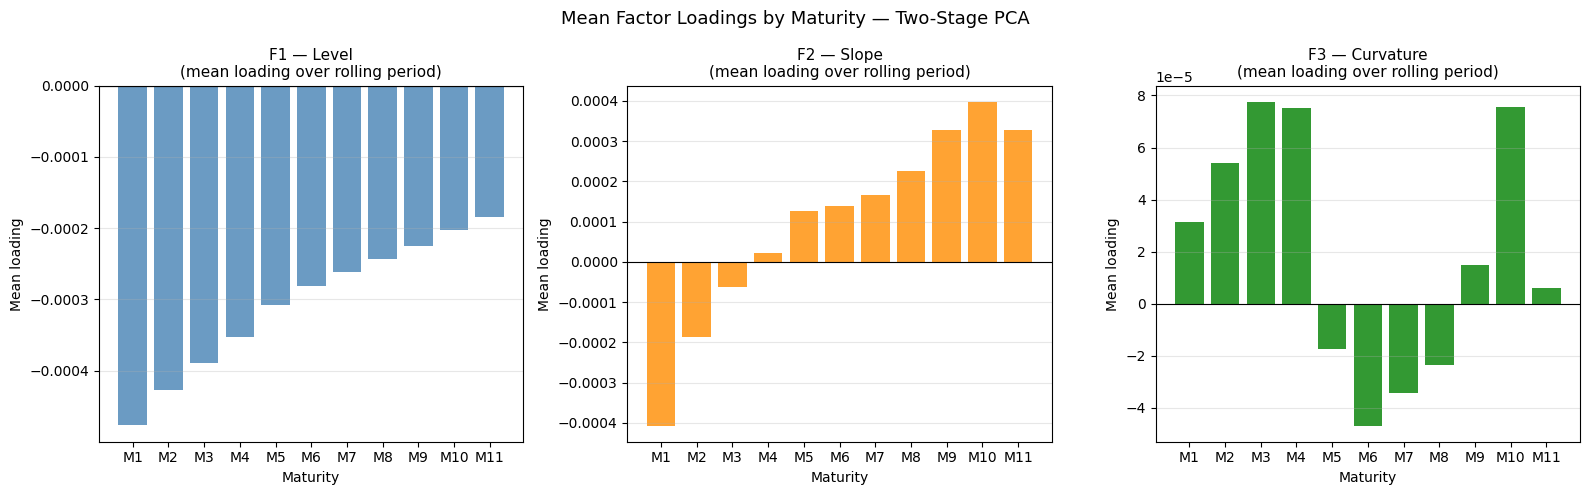

In [34]:
# Mean factor loadings over the full rolling period
mean_loadings = (
    df_loadings
    .groupby(["factor", "maturity"])["loading"]
    .mean()
    .reset_index()
)

mean_loadings["mat_num"] = mean_loadings["maturity"].str.extract(r"(\d+)").astype(int)
mean_loadings = mean_loadings.sort_values(["factor", "mat_num"])

fig, axes = plt.subplots(1, M_FACTORS, figsize=(16, 5), sharey=False)

for k, ax in enumerate(axes):
    sub = mean_loadings[mean_loadings["factor"] == k + 1]
    color = ["steelblue", "darkorange", "green"][k]
    
    ax.bar(mat_labels, sub["loading"].values, color=color, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{factor_names[k]}\n(mean loading over rolling period)", fontsize=11)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Mean loading")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Mean Factor Loadings by Maturity — Two-Stage PCA", fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
df_loadings

,date,factor,maturity,loading,sigma_i,window_start,window_end
0,2011-03-04,1,hh_1,-0.000342,0.000672,2010-03-05,2011-03-03
1,2011-03-04,1,hh_2,-0.000315,0.001113,2010-03-05,2011-03-03
2,2011-03-04,1,hh_3,-0.000291,0.000802,2010-03-05,2011-03-03
3,2011-03-04,1,hh_4,-0.000278,0.000768,2010-03-05,2011-03-03
4,2011-03-04,1,hh_5,-0.000266,0.000661,2010-03-05,2011-03-03
...,...,...,...,...,...,...,...
124636,2026-03-04,3,hh_7,0.000888,0.002628,2025-03-03,2026-03-03
124637,2026-03-04,3,hh_8,0.000494,0.002161,2025-03-03,2026-03-03
124638,2026-03-04,3,hh_9,0.000237,0.002280,2025-03-03,2026-03-03
124639,2026-03-04,3,hh_10,0.000511,0.003320,2025-03-03,2026-03-03


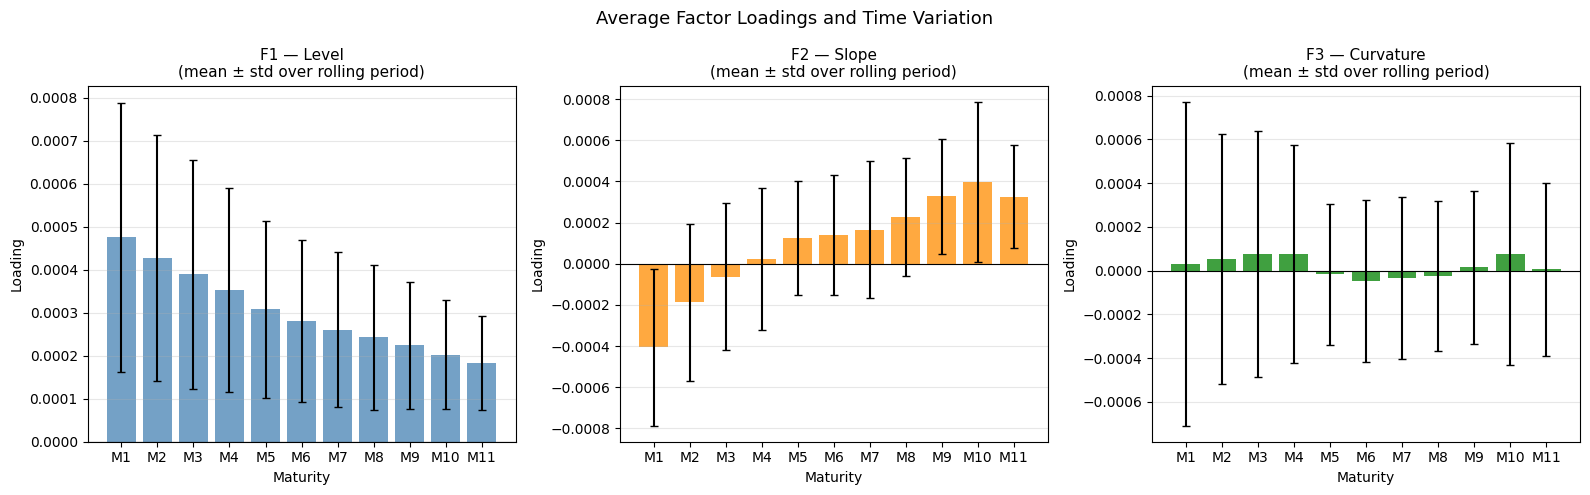

In [36]:
loading_stats = (
    df_loadings
    .groupby(["factor", "maturity"])["loading"]
    .agg(["mean", "std"])
    .reset_index()
)

loading_stats["mat_num"] = loading_stats["maturity"].str.extract(r"(\d+)").astype(int)
loading_stats = loading_stats.sort_values(["factor", "mat_num"])

fig, axes = plt.subplots(1, M_FACTORS, figsize=(16, 5), sharey=False)

for k, ax in enumerate(axes):
    sub = loading_stats[loading_stats["factor"] == k + 1].copy()
    # PCA eigenvectors have arbitrary sign — flip so mean loading is positive
    if sub["mean"].mean() < 0:
        sub["mean"] = -sub["mean"]
    color = ["steelblue", "darkorange", "green"][k]
    
    ax.bar(mat_labels, sub["mean"].values, yerr=sub["std"].values,
           color=color, alpha=0.75, capsize=3)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{factor_names[k]}\n(mean ± std over rolling period)", fontsize=11)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Loading")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Average Factor Loadings and Time Variation", fontsize=13)
plt.tight_layout()
plt.show()

What we want:
- F1 / Level: same sign across maturities.
- F2 / Slope: front-end and back-end should have opposite signs.
- F3 / Curvature: belly should move differently from wings.

Interpretation:
- F1 has the same sign across all maturities, so it is a level-type factor. It is not perfectly flat, but this is normal because the two-stage model scales by idiosyncratic volatility.
- F2 separates M1 from the rest of the curve. This is more a front-month vs rest-of-curve factor than a smooth slope factor.
- F3 has a non-monotonic shape, with positive and negative regions across the curve. This supports a curvature/intermediate-shape interpretation, but it is not a perfectly textbook curvature factor.


F1 = Level / common curve factor

F2 = Front-end slope / short-end dislocation factor

F3 = Curvature / local shape factor


The rolling two-stage PCA identifies a stable first factor corresponding to a
common level movement of the Henry Hub curve. The second factor has a clear
average slope interpretation, separating the front end from the back end of the
curve, although its shape varies across regimes. The third factor captures
curvature/local shape effects, but it is less stable and should be interpreted
more cautiously.

This supports using m = 3 as the baseline, while keeping m = 2 as a robustness
check.

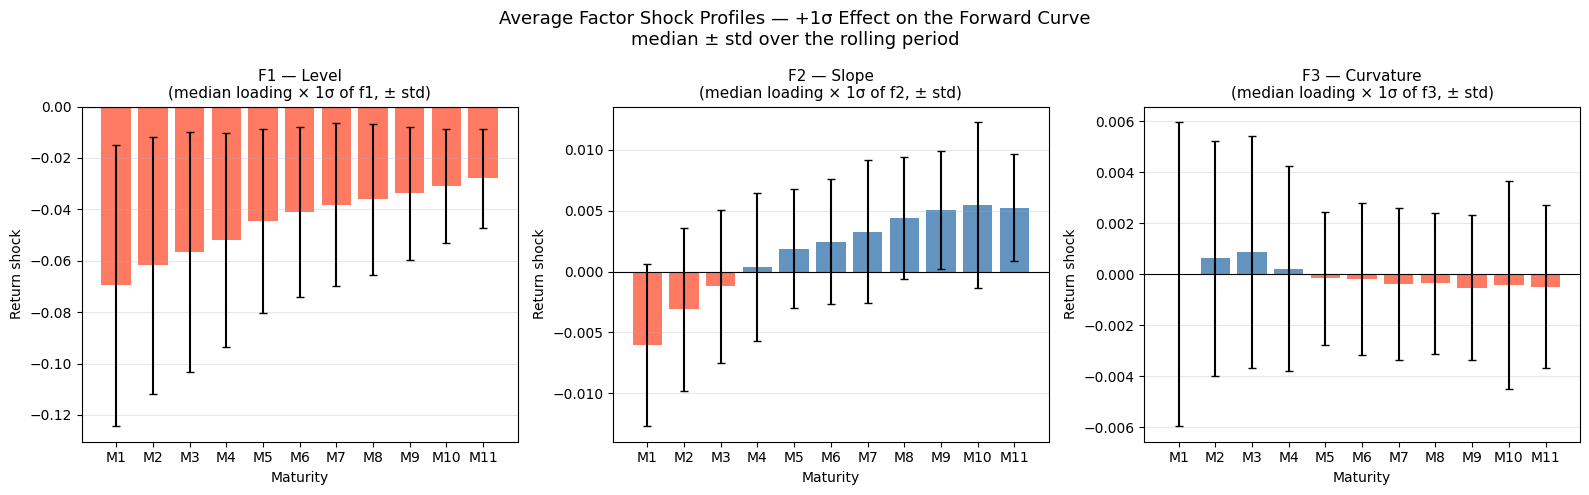

Factor return 1σ over rolling period:
  F1: daily σ = 174.825999
  F2: daily σ = 17.521460
  F3: daily σ = 8.074533


In [87]:
# ── Average factor shock interpretation ───────────────────────────────────
# What does a +1σ shock to each factor look like on the forward curve,
# on average over the rolling period?
#
# shock_{i,k,t} = B_{i,k,t} * std(f_k)
#
# We plot median shock ± std shock across rolling dates.

f_std = df_factors.std()   # 1σ per factor over full rolling history

loadings_wide = (
    df_loadings
    .pivot_table(
        index=["date", "maturity"],
        columns="factor",
        values="loading"
    )
    .reset_index()
)

loadings_wide["mat_num"] = loadings_wide["maturity"].str.extract(r"(\d+)").astype(int)
loadings_wide = loadings_wide.sort_values(["date", "mat_num"])

shock_rows = []

for k in range(1, M_FACTORS + 1):
    tmp = loadings_wide[["date", "maturity", "mat_num", k]].copy()
    tmp = tmp.rename(columns={k: "loading"})
    tmp["factor"] = k
    tmp["shock"] = tmp["loading"] * f_std.loc[f"f{k}"]
    shock_rows.append(tmp)

shock_df = pd.concat(shock_rows, ignore_index=True)

shock_stats = (
    shock_df
    .groupby(["factor", "maturity", "mat_num"])["shock"]
    .agg(["median", "std"])
    .reset_index()
    .sort_values(["factor", "mat_num"])
)

fig, axes = plt.subplots(1, M_FACTORS, figsize=(16, 5), sharey=False)

for k, ax in enumerate(axes, start=1):
    sub = shock_stats[shock_stats["factor"] == k].sort_values("mat_num")
    
    median_shock = sub["median"].values
    std_shock = sub["std"].values
    
    colors_bar = ["tomato" if v < 0 else "steelblue" for v in median_shock]
    
    ax.bar(
        mat_labels,
        median_shock,
        yerr=std_shock,
        color=colors_bar,
        alpha=0.85,
        capsize=3,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"{factor_names[k-1]}\n(median loading × 1σ of f{k}, ± std)",
        fontsize=11,
    )
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Return shock")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Average Factor Shock Profiles — +1σ Effect on the Forward Curve\n"
    "median ± std over the rolling period",
    fontsize=13,
)
plt.tight_layout()
plt.show()

print("Factor return 1σ over rolling period:")
for k in range(1, M_FACTORS + 1):
    print(f"  F{k}: daily σ = {f_std.loc[f'f{k}']:.6f}")

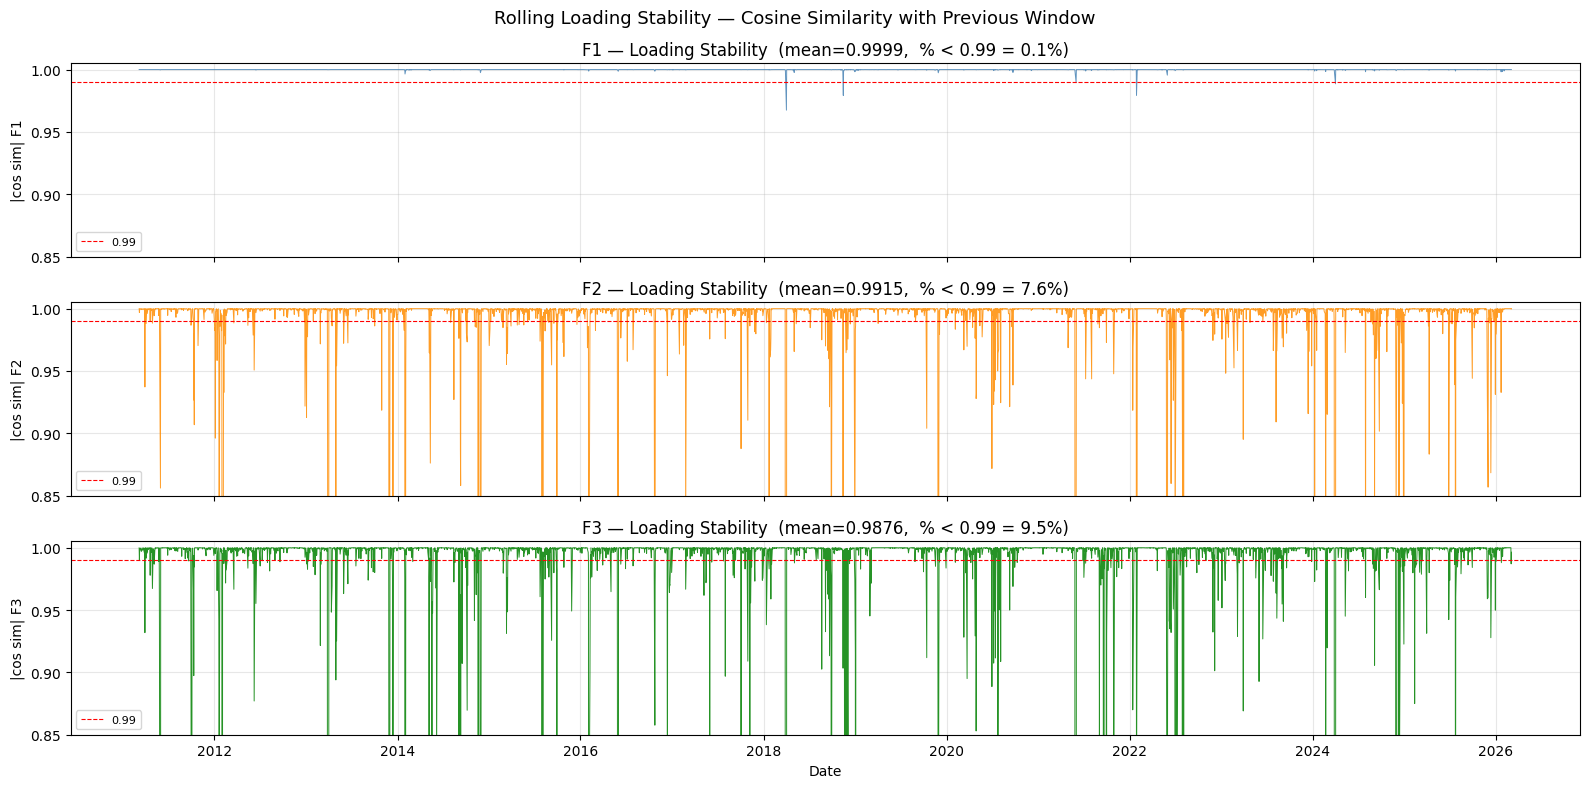

In [88]:

# ── Loading stability through time (cosine similarity) ────────────────────
# After sign alignment, cosine sim should stay near 1.0.
# Dips indicate genuine factor rotation — worth monitoring.

cos_cols = [f"cos_sim_f{k+1}" for k in range(M_FACTORS)]
cs = df_diagnostics[cos_cols].dropna()

fig, axes = plt.subplots(M_FACTORS, 1, figsize=(16, 8), sharex=True)
for k, ax in enumerate(axes):
    col = f"cos_sim_f{k+1}"
    ax.plot(cs.index, cs[col], linewidth=0.7,
            color=["steelblue","darkorange","green"][k], alpha=0.85)
    ax.axhline(0.99, color="red", linestyle="--", linewidth=0.8, label="0.99")
    ax.set_ylim(0.85, 1.005)
    ax.set_ylabel(f"|cos sim| F{k+1}")
    ax.set_title(f"F{k+1} — Loading Stability  (mean={cs[col].mean():.4f},"
                 f"  % < 0.99 = {(cs[col]<0.99).mean()*100:.1f}%)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.suptitle("Rolling Loading Stability — Cosine Similarity with Previous Window",
             fontsize=13)
plt.tight_layout()
plt.show()


This plots cosine similarity between consecutive loading vectors.

What we want: values close to 1.

Interpretation:
- F1 is extremely stable: mean ≈ 0.9998, almost never below 0.99.
- F2 is moderately stable: mean ≈ 0.9736, below 0.99 around 14% of the time.
- F3 is less stable: mean ≈ 0.9638, below 0.99 around 17.9% of the time.

This is normal. The first factor is stable; higher-order factors rotate more. This supports using m=3, but also suggests you should monitor robustness with m=2.


Factor return summary:


,f1,f2,f3
count,3777.000000,3777.000000,3777.000000
mean,1.641665,0.084579,0.080124
std,174.825999,17.521460,8.074533
min,-2823.700111,-177.788331,-120.872316
25%,-45.232925,-6.342970,-2.970259
50%,0.387477,0.189825,0.037392
75%,49.035551,6.935855,3.023038
max,4170.707473,162.195751,132.802274


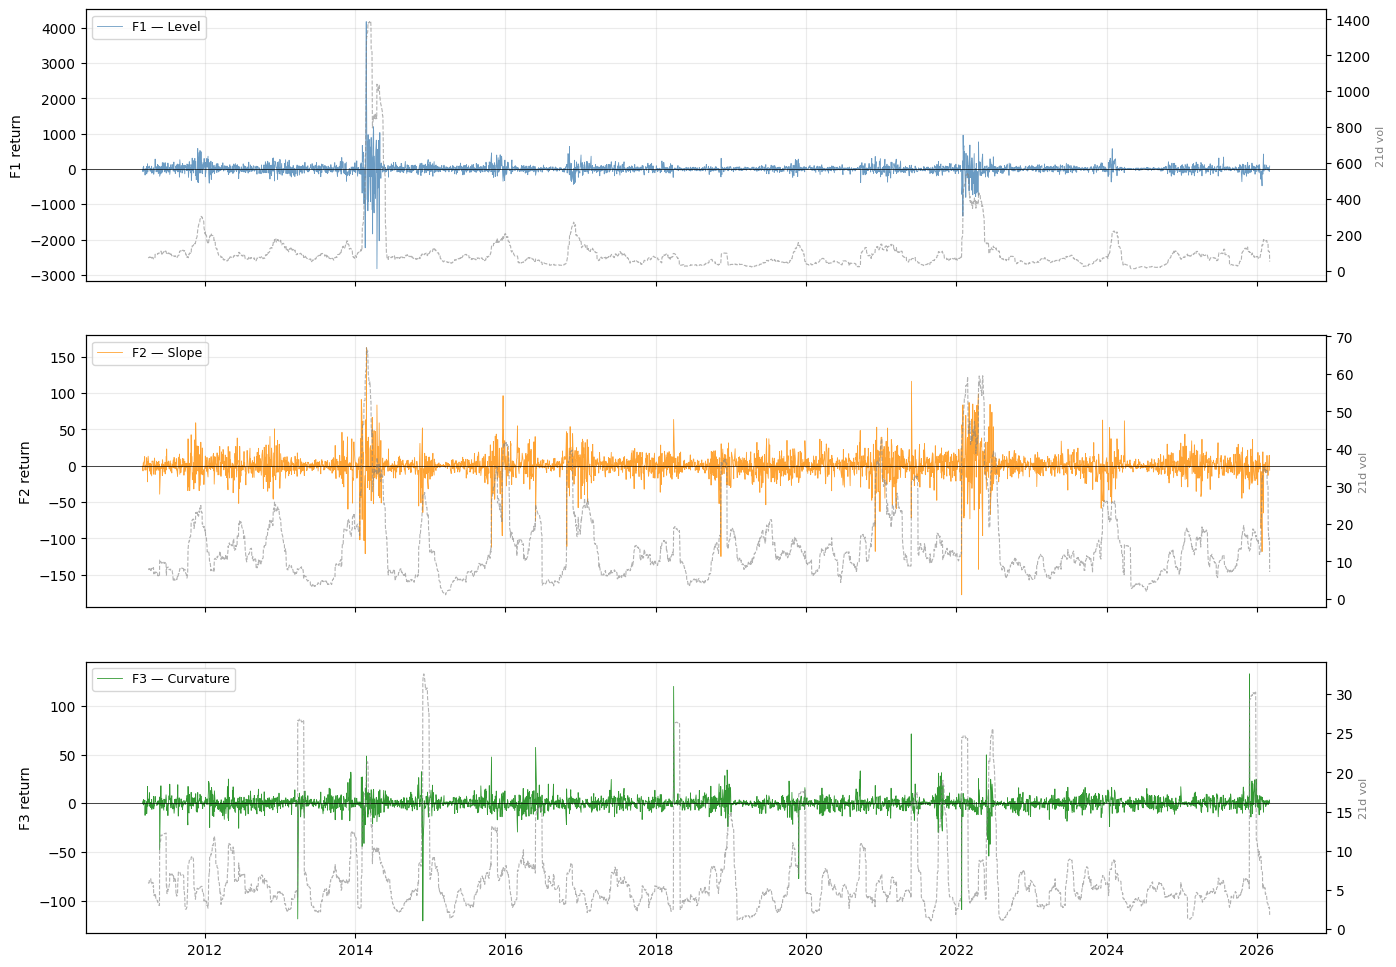

In [89]:

# ── Factor return time series ─────────────────────────────────────────────
# Factor returns should be interpretable as a "level day", "slope day", etc.
# Rolling 21-day vol helps spot volatility regimes in each factor.

fig, axes = plt.subplots(M_FACTORS, 1, figsize=(16, 12), sharex=True)

for k in range(M_FACTORS):
    ax = axes[k]
    f  = df_factors[f"f{k+1}"]
    ax.plot(f.index, f.values, linewidth=0.6, color=["steelblue","darkorange","green"][k],
            alpha=0.8, label=factor_names[k])
    # 21-day rolling vol overlay
    ax2 = ax.twinx()
    ax2.plot(f.index, f.rolling(21).std(), color="grey", linewidth=0.8,
             alpha=0.6, linestyle="--", label="21d vol")
    ax2.set_ylabel("21d vol", fontsize=8, color="grey")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel(f"F{k+1} return")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.25)


print("\nFactor return summary:")
df_factors.describe().round(6)


# EDA Residuals

In [44]:
df_residuals.describe().round(6)

,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
count,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000
mean,-0.000114,-0.000512,-0.000483,-0.000150,-0.000059,0.000108,0.000150,0.000156,0.000203,0.000151,0.000304
std,0.009081,0.008224,0.007847,0.007406,0.006823,0.007031,0.007182,0.007100,0.007711,0.009097,0.007389
min,-0.083586,-0.133634,-0.130399,-0.119919,-0.096503,-0.082303,-0.095396,-0.065442,-0.171936,-0.305615,-0.150905
25%,-0.002724,-0.002640,-0.002393,-0.002024,-0.001957,-0.001904,-0.002020,-0.002092,-0.002252,-0.002376,-0.002457
50%,-0.000035,-0.000333,-0.000240,-0.000128,-0.000043,0.000118,0.000122,0.000116,0.000122,0.000196,0.000205
75%,0.002797,0.002119,0.001890,0.001816,0.001895,0.002195,0.002456,0.002594,0.002765,0.002825,0.003009
max,0.166601,0.094224,0.060596,0.084529,0.046542,0.066950,0.075324,0.095339,0.123705,0.146994,0.099806


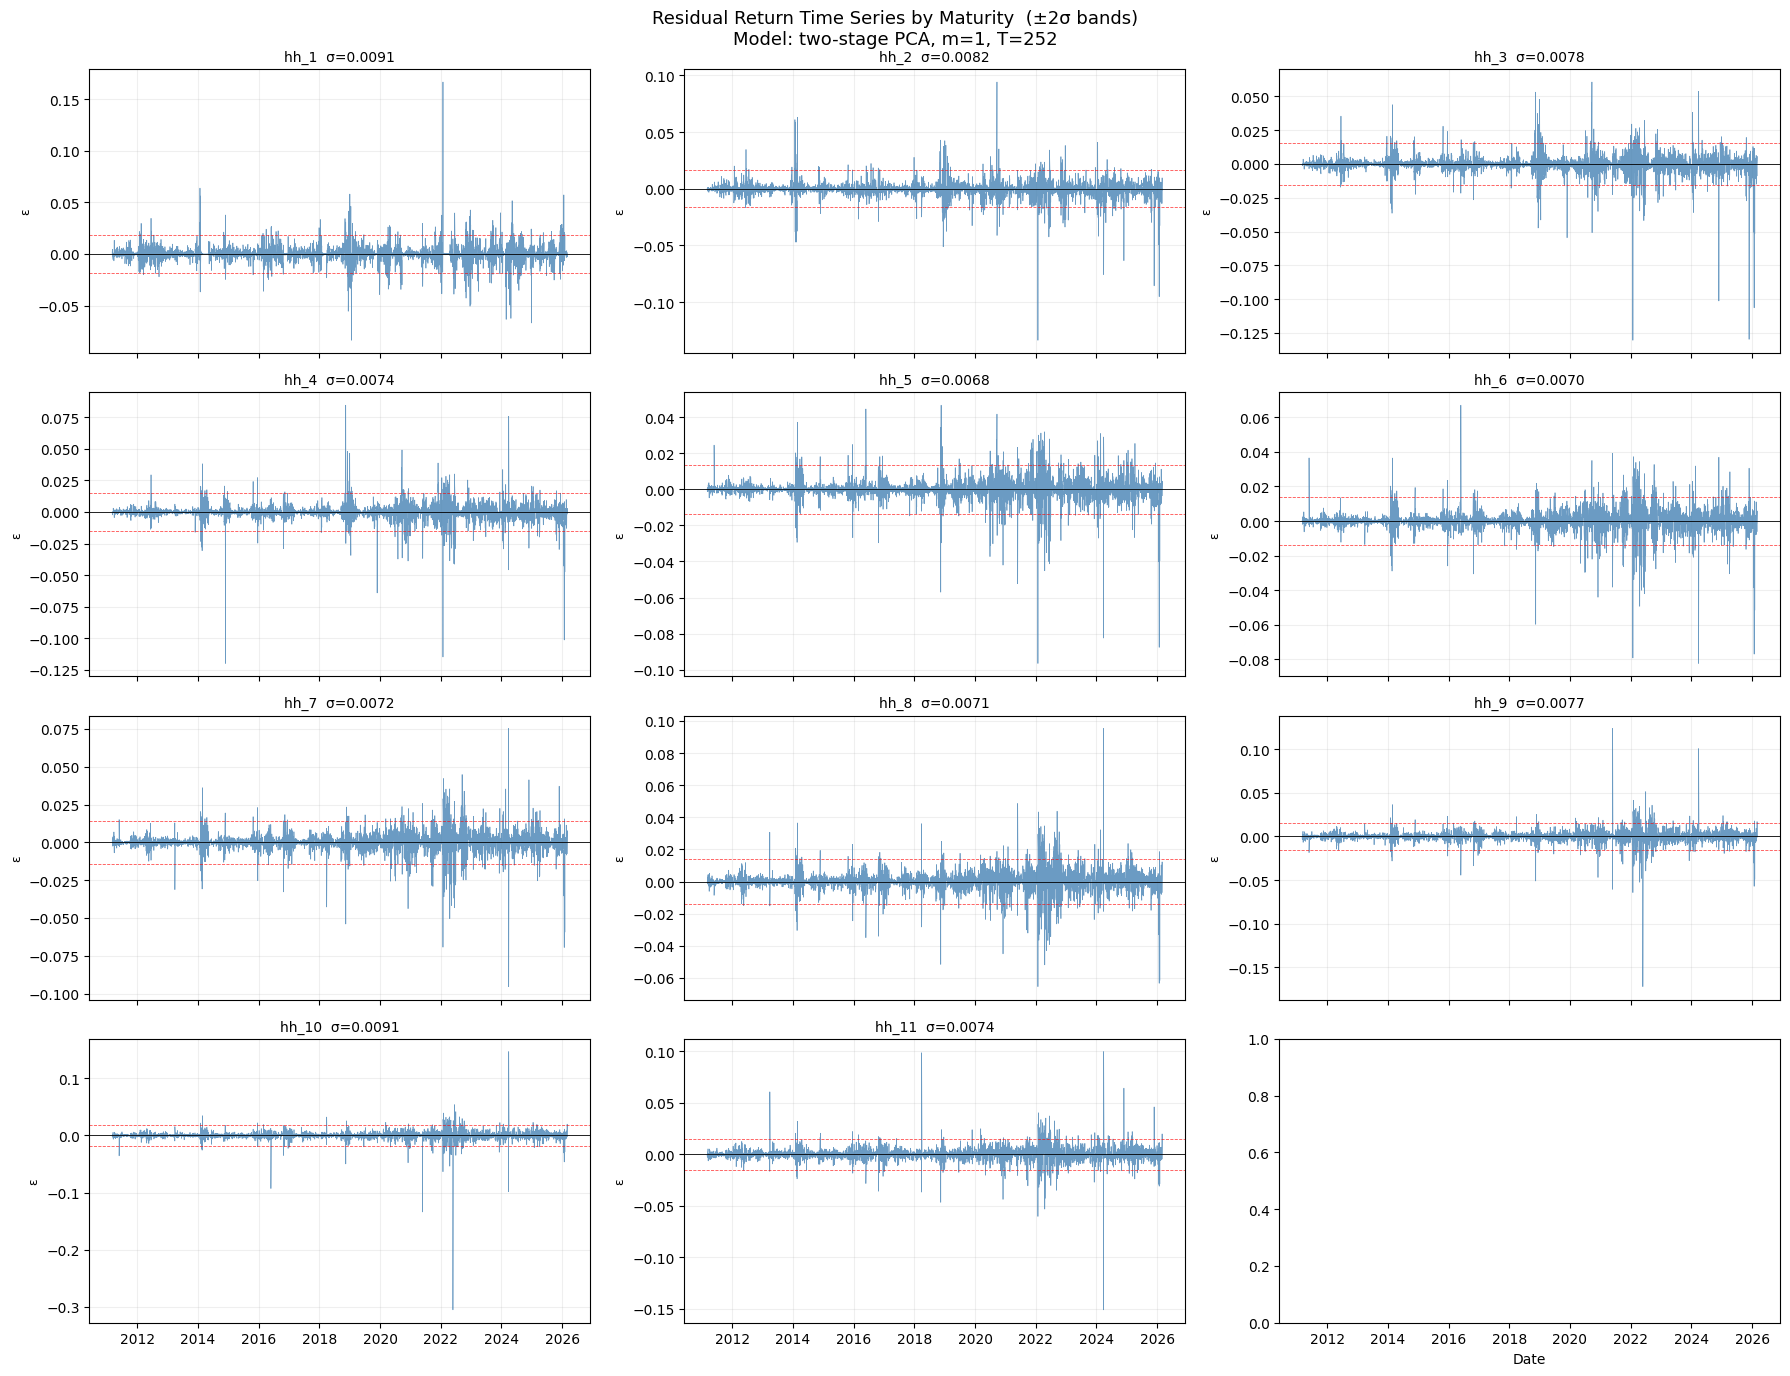

In [45]:
# ── Residual return time series ───────────────────────────────────────────
# These are the relative-value signals: ε_t = r_t − B_t f_t
# Should look like noise around zero with no persistent trends.
# Spikes = mispricings (what the strategy is trying to exploit).

fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharex=True)
axes = axes.flatten()

for i, col in enumerate(price_cols):
    ax  = axes[i]
    eps = df_residuals[col]
    ax.plot(eps.index, eps.values, linewidth=0.5, color="steelblue", alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.6)
    # ±2σ bands
    sig = eps.std()
    ax.axhline( 2 * sig, color="red",   linestyle="--", linewidth=0.6, alpha=0.7)
    ax.axhline(-2 * sig, color="red",   linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_title(f"{col}  σ={sig:.4f}", fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.set_ylabel("ε", fontsize=9)

axes[-1].set_xlabel("Date")
plt.suptitle(
    f"Residual Return Time Series by Maturity  (±2σ bands)\n"
    f"Model: two-stage PCA, m={M_FACTORS}, T={T_WINDOW}",
    fontsize=13,
)
plt.tight_layout()
plt.show()


Interprétation : si les résidus oscillent autour de zéro avec des pics ponctuels, c’est cohérent avec une stratégie de dislocation/reversion. Les spikes sont justement les périodes où certains contrats bougent anormalement par rapport à la courbe. Ce plot est utile, garde-le.

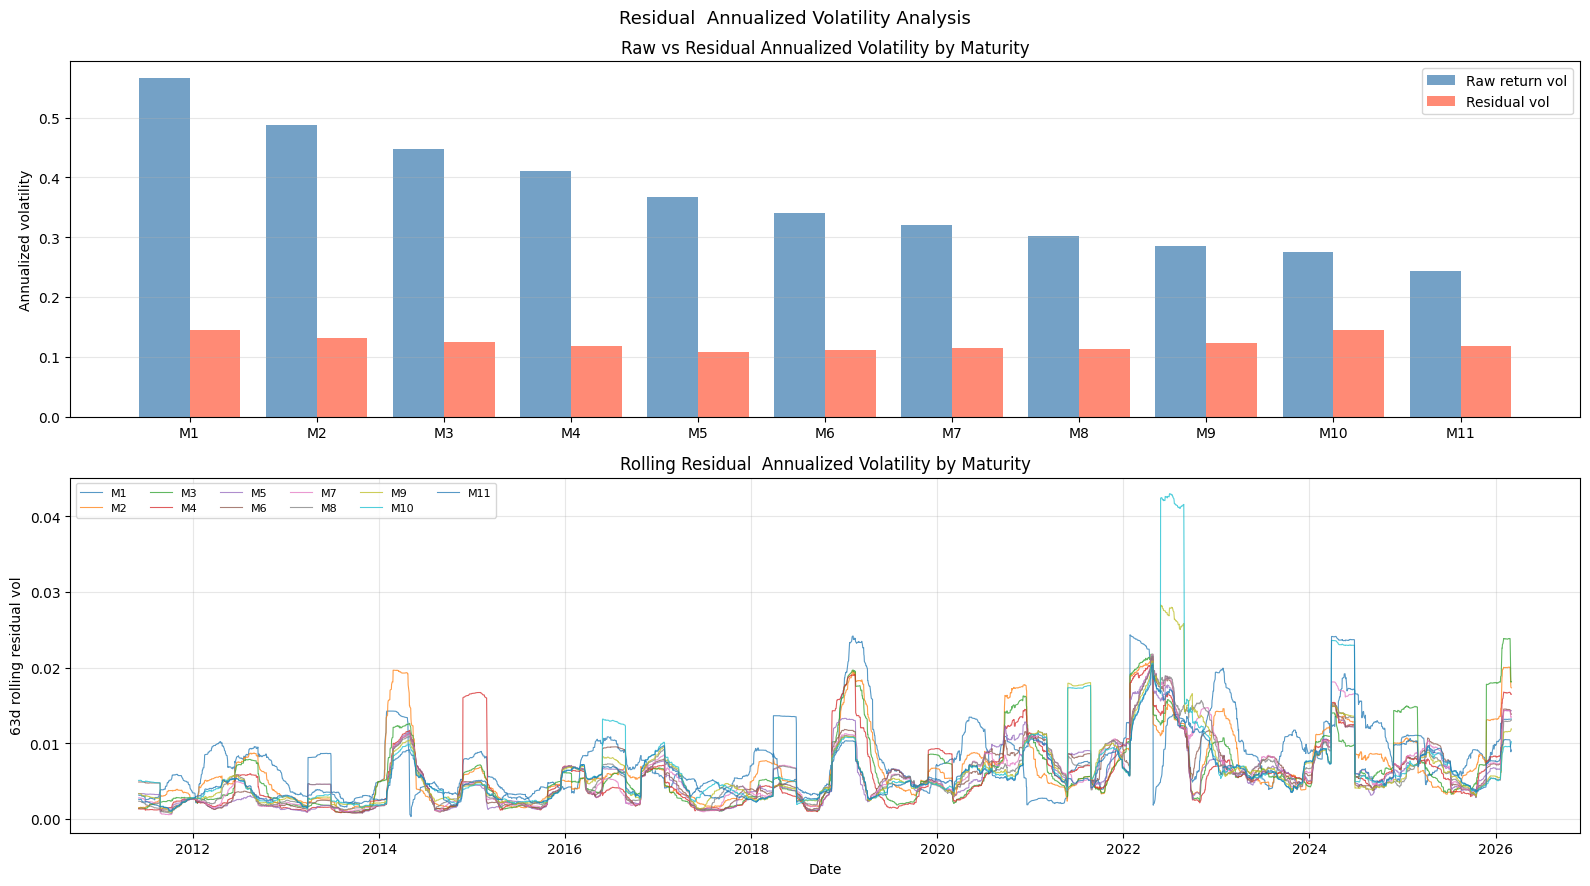

,raw_vol,residual_vol,vol_ratio
hh_1,0.035660,0.009081,0.254654
hh_2,0.030767,0.008224,0.267300
hh_3,0.028252,0.007847,0.277749
hh_4,0.025847,0.007406,0.286541
hh_5,0.023098,0.006823,0.295412
hh_6,0.021501,0.007031,0.326986
hh_7,0.020219,0.007182,0.355204
hh_8,0.019037,0.007100,0.372955
hh_9,0.018016,0.007711,0.428039
hh_10,0.017336,0.009097,0.524746


In [46]:
# ── Residual volatility by maturity ───────────────────────────────────────
# Compare raw daily vol and residual daily vol.
# Residual vol should be materially lower than raw vol.

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

raw_vol = X_df.loc[df_residuals.index, price_cols].std()
eps_vol = df_residuals[price_cols].std()

annual_vol_compare = pd.DataFrame({
    "raw_vol": raw_vol * np.sqrt(252),
    "residual_vol": eps_vol * np.sqrt(252),
    "vol_ratio": eps_vol / raw_vol,
})

vol_compare = pd.DataFrame({
    "raw_vol": raw_vol ,
    "residual_vol": eps_vol ,
    "vol_ratio": eps_vol / raw_vol,
})

x = np.arange(len(price_cols))
w = 0.4

axes[0].bar(x - w/2, annual_vol_compare["raw_vol"].values, width=w,
            label="Raw return vol", color="steelblue", alpha=0.75)
axes[0].bar(x + w/2, annual_vol_compare["residual_vol"].values, width=w,
            label="Residual vol", color="tomato", alpha=0.75)

axes[0].set_xticks(x)
axes[0].set_xticklabels(mat_labels)
axes[0].set_ylabel("Annualized volatility")
axes[0].set_title("Raw vs Residual Annualized Volatility by Maturity")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

roll_eps_vol = df_residuals[price_cols].rolling(63).std()

for i, col in enumerate(price_cols):
    axes[1].plot(
        roll_eps_vol.index,
        roll_eps_vol[col],
        label=f"M{i+1}",
        linewidth=0.8,
        alpha=0.75,
    )

axes[1].set_ylabel("63d rolling residual vol")
axes[1].set_xlabel("Date")
axes[1].set_title("Rolling Residual  Annualized Volatility by Maturity")
axes[1].legend(ncol=6, fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Residual  Annualized Volatility Analysis", fontsize=13)
plt.tight_layout()
plt.show()

vol_compare.round(6)

Pour M1-M3, le ratio est environ 0.22–0.28 : le modèle explique énormément de la variation du front. Pour M12, le ratio monte à 0.56 : le modèle explique encore une partie importante, mais moins que sur le front. Cela veut dire que le back-end contient plus de variation spécifique ou moins bien capturée par les 3 facteurs.

Sur le rolling residual volatility plot, on voit aussi que la volatilité résiduelle est régime-dépendante : elle augmente beaucoup autour des périodes de stress, notamment après 2021/2022. Donc même après avoir retiré les facteurs communs, il reste des épisodes de dislocation plus violents.

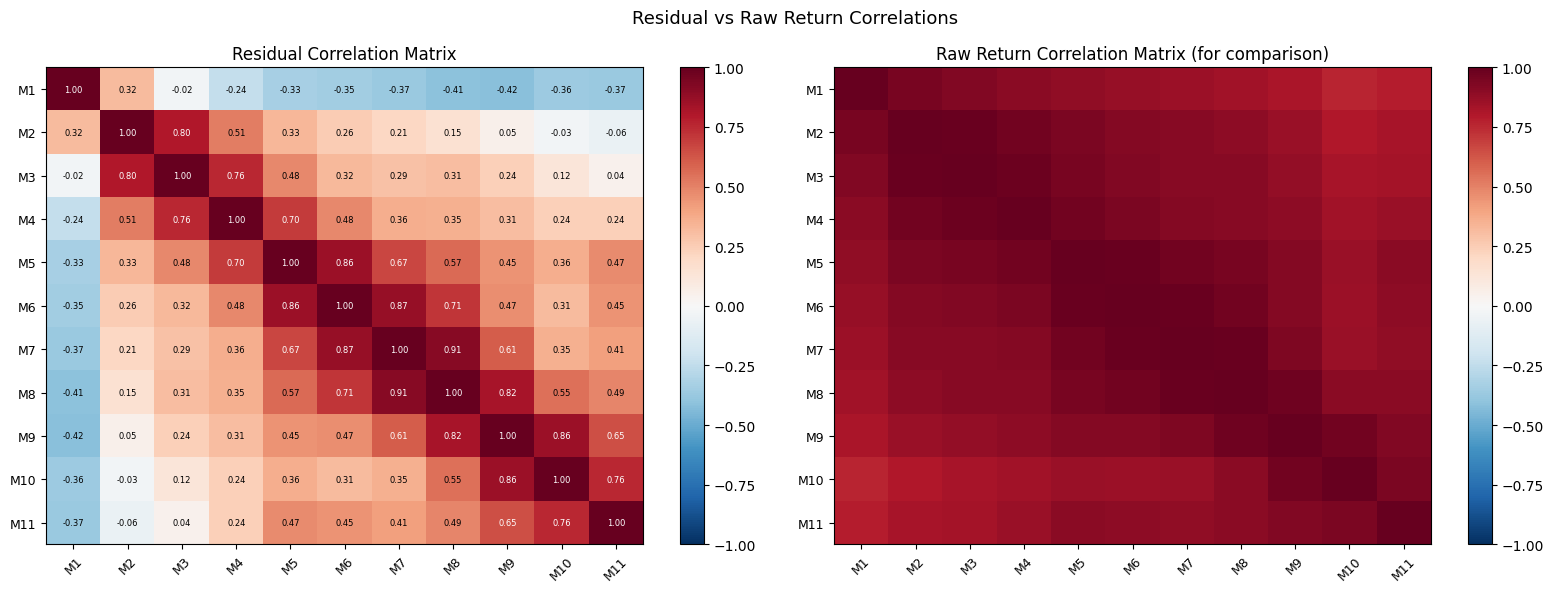

Residual: mean |off-diag corr| = 0.4254  max = 0.9067
Raw:      mean |off-diag corr| = 0.9038  max = 0.9875


In [47]:
# ── Residual correlation matrix ───────────────────────────────────────────
# After a good factor decomposition, residuals should be weakly correlated.
# High off-diagonal entries suggest the factor model is underfitting or that
# a 4th factor should be kept.

import matplotlib.ticker as mticker

corr = df_residuals[price_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual correlation
im0 = axes[0].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[0].set_xticks(range(N)); axes[0].set_xticklabels(mat_labels, rotation=45, fontsize=9)
axes[0].set_yticks(range(N)); axes[0].set_yticklabels(mat_labels, fontsize=9)
axes[0].set_title("Residual Correlation Matrix", fontsize=12)
plt.colorbar(im0, ax=axes[0])
for i in range(N):
    for j in range(N):
        axes[0].text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                     fontsize=6, color="black" if abs(corr.values[i,j]) < 0.6 else "white")

# Raw return correlation for comparison
raw_corr = X_df.loc[df_residuals.index, price_cols].corr()
im1 = axes[1].imshow(raw_corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(N)); axes[1].set_xticklabels(mat_labels, rotation=45, fontsize=9)
axes[1].set_yticks(range(N)); axes[1].set_yticklabels(mat_labels, fontsize=9)
axes[1].set_title("Raw Return Correlation Matrix (for comparison)", fontsize=12)
plt.colorbar(im1, ax=axes[1])

plt.suptitle("Residual vs Raw Return Correlations", fontsize=13)
plt.tight_layout()
plt.show()

# Off-diagonal mean absolute correlation
off_diag = corr.values[np.triu_indices(N, k=1)]
print(f"Residual: mean |off-diag corr| = {np.mean(np.abs(off_diag)):.4f}"
      f"  max = {np.max(np.abs(off_diag)):.4f}")
off_diag_raw = raw_corr.values[np.triu_indices(N, k=1)]
print(f"Raw:      mean |off-diag corr| = {np.mean(np.abs(off_diag_raw)):.4f}"
      f"  max = {np.max(np.abs(off_diag_raw)):.4f}")


Les résidus sont beaucoup moins corrélés que les returns bruts.
	​
Donc le modèle retire bien le mouvement commun de la courbe. Il reste quelques corrélations locales, par exemple autour de maturités voisines, mais c’est normal : une PCA à 3 facteurs ne doit pas annihiler toute structure, sinon tu sur-filtrerais.

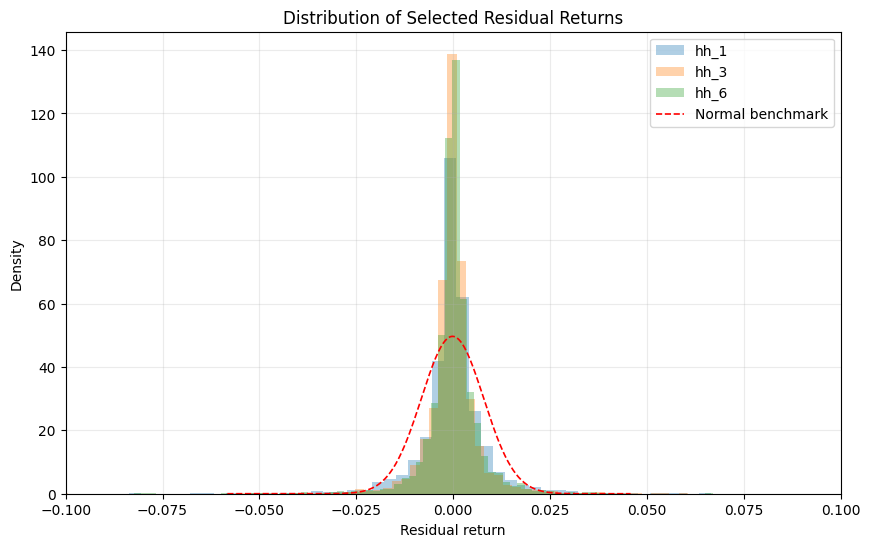

Residual summary stats:
           mean       std       skew  excess_kurtosis
hh_1  -0.000114  0.009081   1.274304        39.165830
hh_2  -0.000512  0.008224  -1.763405        39.749977
hh_3  -0.000483  0.007847  -3.646453        62.560422
hh_4  -0.000150  0.007406  -2.287684        57.494955
hh_5  -0.000059  0.006823  -2.088705        31.882180
hh_6   0.000108  0.007031  -1.331202        23.109907
hh_7   0.000150  0.007182  -1.178801        23.847506
hh_8   0.000156  0.007100  -0.158659        20.639326
hh_9   0.000203  0.007711  -1.955431        97.743109
hh_10  0.000151  0.009097 -10.580264       376.101375
hh_11  0.000304  0.007389  -1.050571        70.742437


In [48]:
# ── Residual distribution — histograms + KDE ─────────────────────────────
# Want near-Gaussian, mean ≈ 0, no heavy fat tails that suggest lingering
# common factor exposure.

from scipy import stats as sp_stats

'''fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(price_cols):
    ax  = axes[i]
    eps = df_residuals[col].dropna()
    ax.hist(eps, bins=80, density=True, color="steelblue", alpha=0.55,
            label="Residual")
    # KDE
    xg = np.linspace(eps.quantile(0.001), eps.quantile(0.999), 300)
    kde = sp_stats.gaussian_kde(eps)
    ax.plot(xg, kde(xg), color="steelblue", linewidth=1.5)
    # Normal overlay with same mean/std
    ax.plot(xg, sp_stats.norm.pdf(xg, eps.mean(), eps.std()),
            color="red", linewidth=1.2, linestyle="--", label="Normal")
    ax.set_title(f"{col}  (κ={sp_stats.kurtosis(eps):.1f})", fontsize=10)
    ax.set_xlabel("ε")
    if i == 0:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle("Residual Distributions by Maturity (excess kurtosis shown)", fontsize=13)
plt.tight_layout()
plt.show()
'''

sel_cols = ["hh_1", "hh_3", "hh_6"]

plt.figure(figsize=(10, 6))

for col in sel_cols:
    eps_col = df_residuals[col].dropna()
    plt.hist(eps_col, bins=80, alpha=0.35, density=True, label=col)

all_eps = df_residuals[sel_cols].stack().dropna()
xg = np.linspace(all_eps.quantile(0.001), all_eps.quantile(0.999), 300)

plt.plot(
    xg,
    sp_stats.norm.pdf(xg, all_eps.mean(), all_eps.std()),
    color="red",
    linewidth=1.2,
    linestyle="--",
    label="Normal benchmark",
)

plt.title("Distribution of Selected Residual Returns")
plt.xlabel("Residual return")
plt.ylabel("Density")
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


# Summary stats
print("Residual summary stats:")
eps_stats = df_residuals.agg(["mean","std","skew",
                               lambda x: sp_stats.kurtosis(x)]).T
eps_stats.columns = ["mean","std","skew","excess_kurtosis"]
print(eps_stats.round(6).to_string())


In [49]:
# ── Stationarity and R² diagnostics ──────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

print("=== ADF Stationarity Test on Residuals (H0: unit root) ===\n")
print(f"{'Maturity':<10}  {'ADF stat':>10}  {'p-value':>10}  {'Stationary?':>12}")
print("-" * 50)
for col in price_cols:
    series = df_residuals[col].dropna()
    adf_stat, p_val, *_ = adfuller(series, autolag="AIC")
    flag = "YES" if p_val < 0.05 else "NO *"
    print(f"{col:<10}  {adf_stat:>10.4f}  {p_val:>10.4f}  {flag:>12}")

# ── Raw vs Fitted R² per maturity ─────────────────────────────────────────
import statsmodels.api as sm

def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# Align raw returns and factor returns
Y_raw = X_df.loc[df_factors.index, price_cols].copy()
F = df_factors[[f"f{k+1}" for k in range(M_FACTORS)]].copy()

X_reg = sm.add_constant(F)

rows = []

for col in price_cols:
    y = Y_raw[col].dropna()
    X_i = X_reg.loc[y.index]

    # HAC/Newey-West standard errors are safer for daily financial returns
    model = sm.OLS(y, X_i).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    eps = df_residuals.loc[y.index, col]
    raw = Y_raw.loc[y.index, col]

    ss_tot = ((raw - raw.mean()) ** 2).sum()
    ss_res = (eps ** 2).sum()
    r2_factor_decomp = 1 - ss_res / ss_tot

    row = {
        "maturity": col,
        "R2_factor_decomp": r2_factor_decomp,
        "OLS_R2_raw_on_factors": model.rsquared,
        "resid_vol": eps.std(),
        "raw_vol": raw.std(),
        "vol_ratio": eps.std() / raw.std(),
        "alpha": model.params["const"],
        "alpha_pval": model.pvalues["const"],
    }

    for k in range(M_FACTORS):
        fcol = f"f{k+1}"
        beta = model.params[fcol]
        pval = model.pvalues[fcol]

        row[f"beta_{fcol}"] = beta
        row[f"pval_{fcol}"] = pval
        row[f"sig_{fcol}"] = significance_stars(pval)
        row[f"beta_{fcol}_sig"] = f"{beta:.6g}{significance_stars(pval)}"

    rows.append(row)

r2_beta_table = pd.DataFrame(rows).set_index("maturity")

display_cols = (
    ["R2_factor_decomp", "OLS_R2_raw_on_factors", "resid_vol", "raw_vol", "vol_ratio"]
    + [f"beta_f{k+1}_sig" for k in range(M_FACTORS)]
)

r2_beta_table[display_cols].round(6)

=== ADF Stationarity Test on Residuals (H0: unit root) ===

Maturity      ADF stat     p-value   Stationary?
--------------------------------------------------
hh_1          -10.9783      0.0000           YES
hh_2          -15.3883      0.0000           YES
hh_3          -11.2933      0.0000           YES
hh_4          -11.2992      0.0000           YES
hh_5          -11.3357      0.0000           YES
hh_6          -44.3246      0.0000           YES
hh_7          -45.3570      0.0000           YES
hh_8           -9.7348      0.0000           YES
hh_9          -10.9718      0.0000           YES
hh_10         -11.5374      0.0000           YES
hh_11         -63.8273      0.0000           YES


,R2_factor_decomp,OLS_R2_raw_on_factors,resid_vol,raw_vol,vol_ratio,beta_f1_sig
maturity,,,,,,
hh_1,0.935141,0.295929,0.009081,0.035660,0.254654,-0.000110959***
hh_2,0.928274,0.274474,0.008224,0.030767,0.267300,-9.21992e-05***
hh_3,0.922563,0.271066,0.007847,0.028252,0.277749,-8.41355e-05***
hh_4,0.917861,0.279486,0.007406,0.025847,0.286541,-7.81614e-05***
hh_5,0.912725,0.293823,0.006823,0.023098,0.295412,-7.16149e-05***
hh_6,0.893055,0.297632,0.007031,0.021501,0.326986,-6.70955e-05***
hh_7,0.873775,0.300460,0.007182,0.020219,0.355204,-6.33952e-05***
hh_8,0.860837,0.306894,0.007100,0.019037,0.372955,-6.03247e-05***
hh_9,0.816655,0.304496,0.007711,0.018016,0.428039,-5.68639e-05***


In [50]:
# Top residual events to inspect
top_resid = (
    df_residuals[price_cols]
    .abs()
    .stack()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_resid.columns = ["date", "maturity", "abs_residual"]
top_resid["residual"] = [
    df_residuals.loc[d, m]
    for d, m in zip(top_resid["date"], top_resid["maturity"])
]

top_resid

,date,maturity,abs_residual,residual
0,2022-05-27,hh_10,0.305615,-0.305615
1,2022-05-27,hh_9,0.171936,-0.171936
2,2022-01-27,hh_1,0.166601,0.166601
3,2024-03-27,hh_11,0.150905,-0.150905
4,2024-03-28,hh_10,0.146994,0.146994
5,2021-05-27,hh_10,0.134046,-0.134046
6,2022-01-27,hh_2,0.133634,-0.133634
7,2022-01-27,hh_3,0.130399,-0.130399
8,2025-11-26,hh_3,0.129703,-0.129703
9,2021-05-28,hh_9,0.123705,0.123705


The two-stage PCA factor model performs well as a residualization engine. 
Residual diagnostics confirm that the two-stage PCA removes most of the common
curve variation. Residual volatility is materially lower than raw return
volatility, and average off-diagonal correlation falls from 0.71 for raw returns
to 0.19 for residuals. This indicates that the residuals are closer to
maturity-specific relative-value components.

The factor model achieves high in-sample R² across maturities, especially on the
front and middle of the curve. The explanatory power declines for longer
maturities, suggesting that the back end contains more maturity-specific or
less-factor-driven variation.

Residuals remain heavy-tailed and sometimes skewed, which is expected in natural
gas markets. This is not necessarily a problem: large residual shocks may
represent genuine curve dislocations and are precisely the type of events the
strategy aims to predict or trade.


The first factor is highly stable and captures the dominant common movement of
the Henry Hub forward curve. The second and third factors are less stable but
capture additional slope/local-shape variation. We therefore keep m=3 as the
baseline, with m=2 and m=4 reserved for robustness checks.

R²

The rolling factor model explains:
- around 92–95% of front/mid front maturities;
- around 78–90% for middle maturities;
- around 68% for M12.

The model removes most of the common curve variation.


Vol ratio


Residual volatility is much lower than raw volatility: σ(ri)/σ(εi)≈0.22 to 0.56

This means your residuals are much cleaner relative-value objects than raw returns.


Correlation
- Raw mean absolute off-diagonal correlation: 0.714
- Residual mean absolute off-diagonal correlation: 0.190


It means the factor model strongly reduces common dependence between maturities.

Factor stability

F1 is very stable. F2 and F3 are less stable, but still interpretable enough for a curve model.

### ACF, Stationarity, and Autocorrelation Structure of Residuals

Key questions before ML:
- **Stationarity** (ADF + KPSS): confirms residuals are safe ML targets.
- **ACF / PACF of ε_t**: reveals whether ε_{t-1} carries predictive signal → informs feature design and target horizon.
- **Ljung-Box on ε_t**: formal autocorrelation test.
- **ARCH effects** (ACF of ε_t²): volatility clustering → relevant for normalising signals.

Done on **M1** (front-end) and **M6** (mid-curve) as representatives — all other maturities behave similarly.

M1 — Residual Stationarity Check

STATIONARITY CHECK (ADF + KPSS, with optional STL)


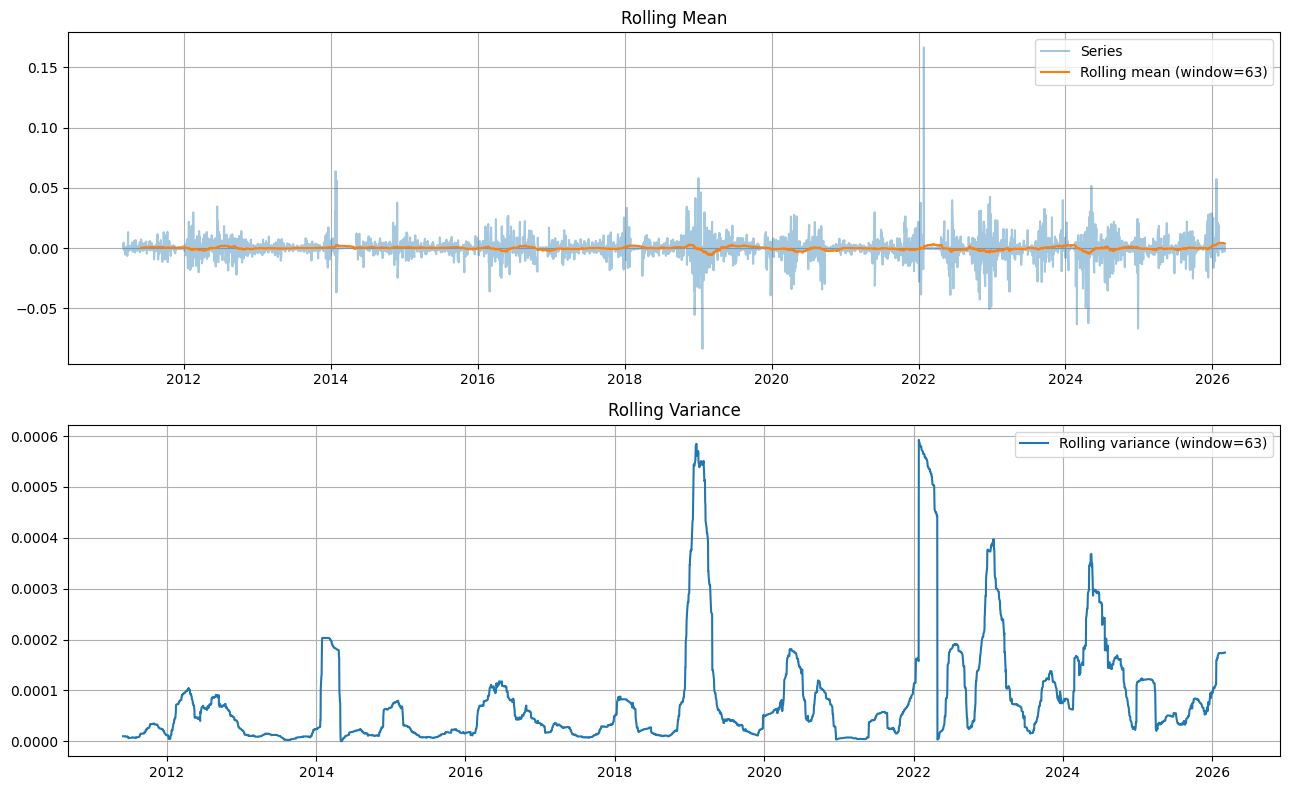

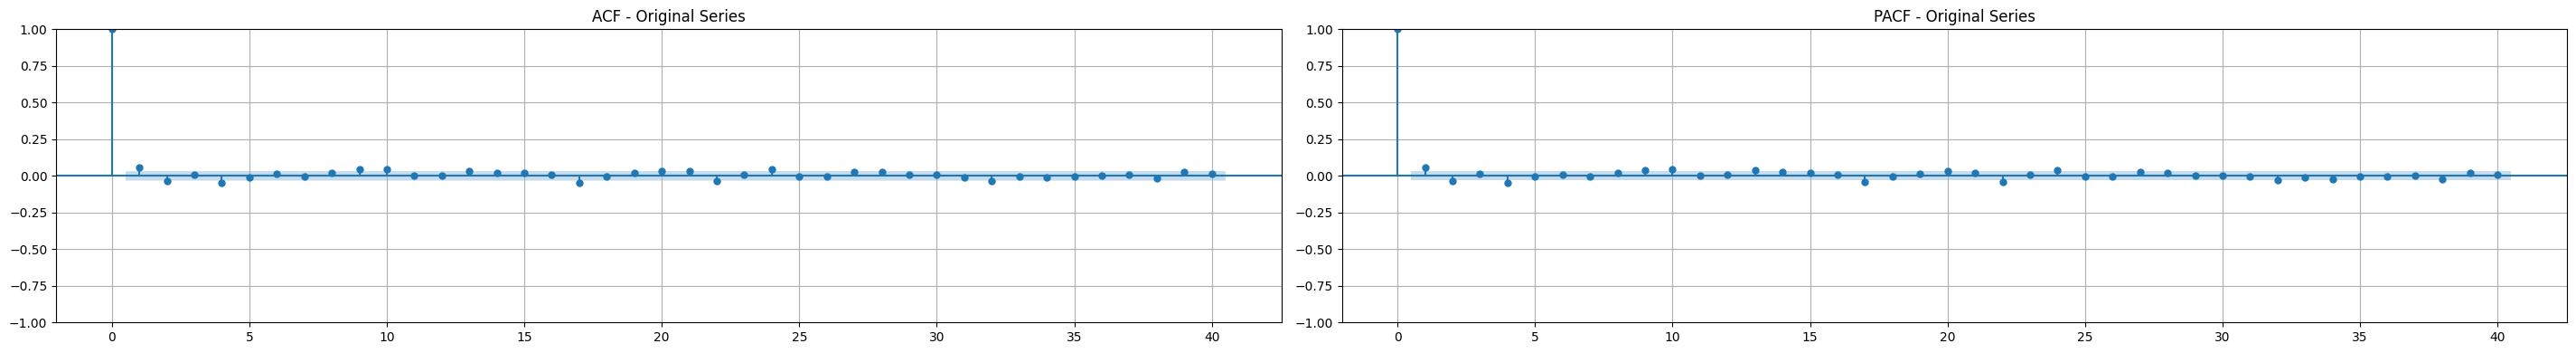


--- Tests on current series ---

Augmented Dickey–Fuller (ADF) test
  H0: Series has a unit root (non-stationary)
  H1: Series is stationary
  Statistic = -10.9783, p-value = 0.0000
  Critical values: {'1%': -3.4320936126640174, '5%': -2.8623104319229618, '10%': -2.5671801115022364}
  ➜ Reject H0 → evidence of stationarity

KPSS test (reg='c' : level stationarity)
  H0: Series is level stationary
  H1: Series is non-stationary
  Statistic = 0.1839, p-value = 0.1000
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  ➜ Fail to reject H0 → series appears level-stationary

KPSS test (reg='ct' : trend stationarity)
  H0: Series is trend-stationary
  H1: Series is non-stationary
  Statistic = 0.0908, p-value = 0.1000
  Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
  ➜ Fail to reject H0 → series appears trend-stationary

Trend regression y_t = a + b t
  slope b = -1.0480e-07
  p-value = 0.4394
  R²      = 0.0002
  ➜ No strong evidence of l

/Users/dnn/Projects/stats_libs/timeseries/stationarity.py:260: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k_res = kpss(series_ts, regression=reg, nlags="auto")
/Users/dnn/Projects/stats_libs/timeseries/stationarity.py:260: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k_res = kpss(series_ts, regression=reg, nlags="auto")


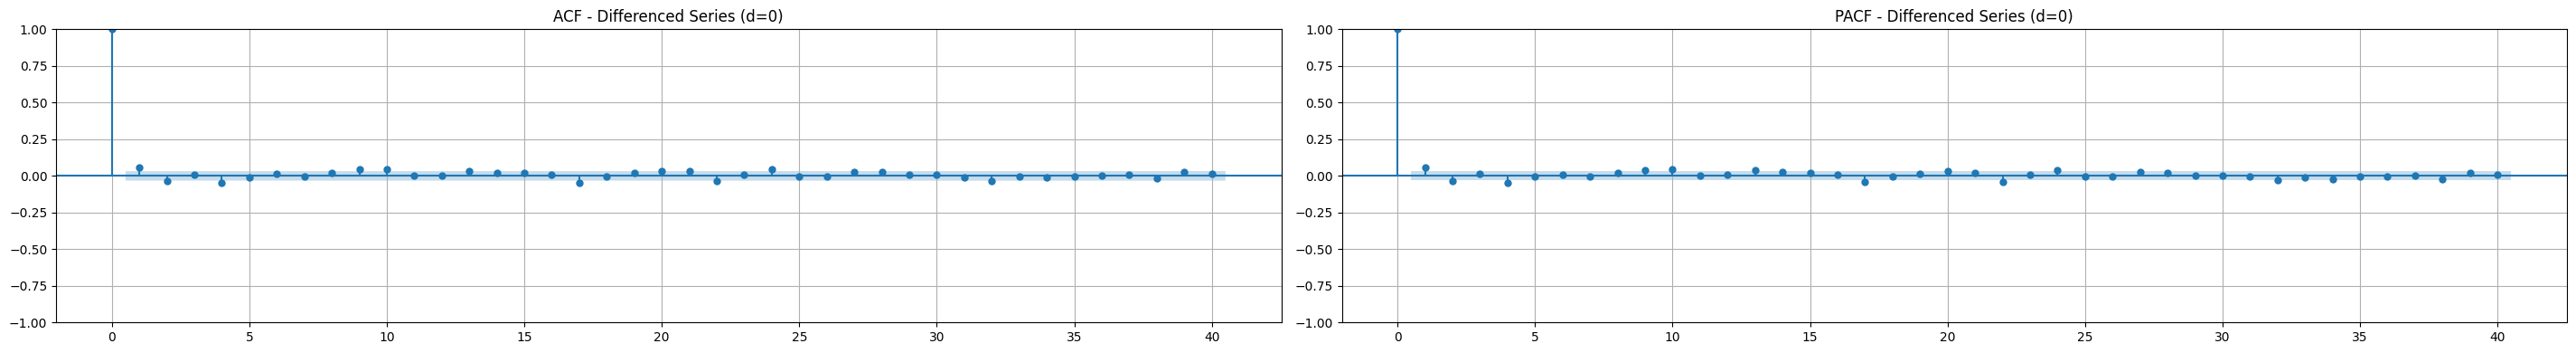

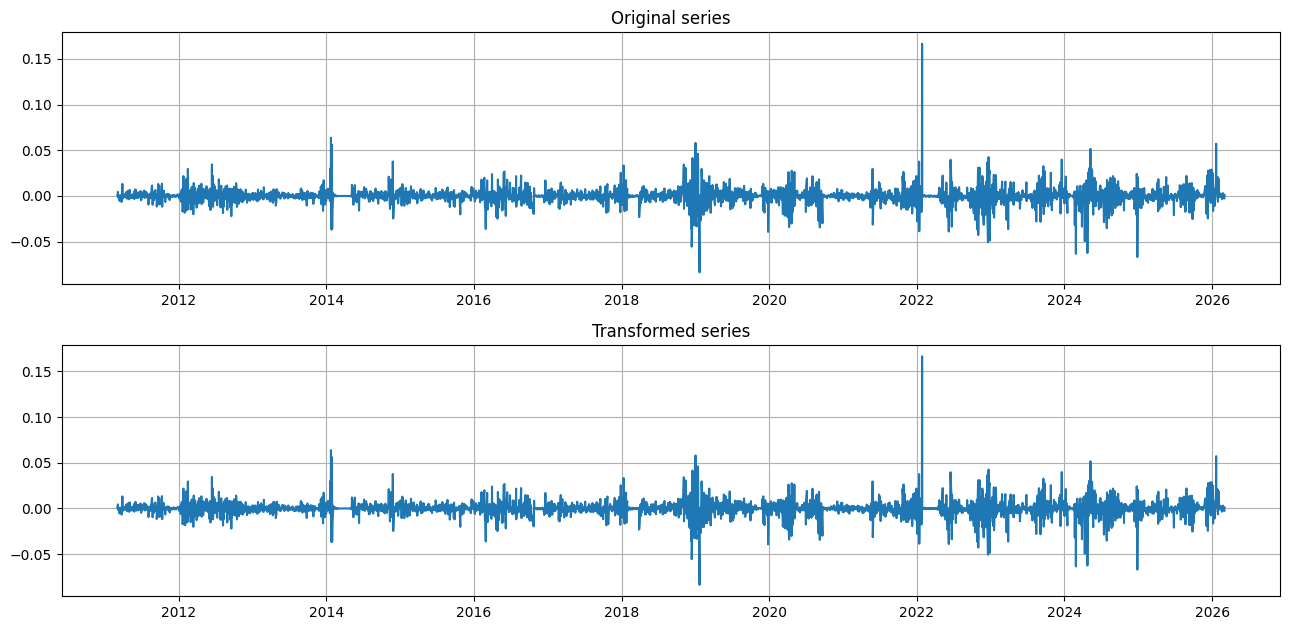


--------------------------------------------------------------------------------
STATIONARITY SUMMARY
--------------------------------------------------------------------------------
  Log transform applied : False
  Differencing order d  : 0
  KPSS version used     : 'c' (level vs trend)
  Final trend slope     : -1.0480e-07 (p = 0.4394)
  Stationary (ADF & KPSS agree): True
  Note: Series appears stationary after log=False, differencing order d=0, using KPSS(reg='c').

Stationarity check complete.



In [51]:
import sys
sys.path.insert(0, "/Users/dnn/Projects/stats_libs/timeseries")
from stationarity import check_stationarity

# M1 — front-end residuals: stationarity check (ADF + KPSS, ACF/PACF, rolling stats)
# difference=False: these are already log-return residuals — should be stationary by construction
print("M1 — Residual Stationarity Check")
_ = check_stationarity(
    df_residuals["hh_1"],
    difference=False,
    kpss_reg="auto",
    rolling_window=63,
    stl_decompose=False,
    show_plots=True,
    verbose=True,
    figsize=(13, 4),
)


M1 — Front-End — Residual Diagnostics
Model type: ARIMA/ARX → expecting raw residuals ε_t.

1. RESIDUALS OVER TIME


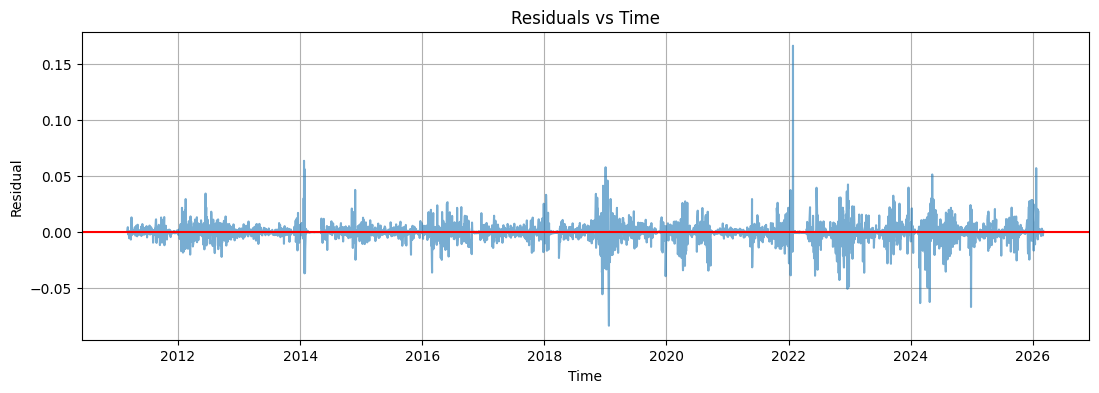


2. NORMALITY OF RESIDUALS

Shapiro–Wilk test
  H0: Residuals follow a normal distribution
  H1: Residuals are not normally distributed
  Statistic = 0.7952,  p-value = 0.0000
  ➜ Reject H0 → Residuals NOT normal

Jarque–Bera test
  H0: Residuals are normal (correct skewness + kurtosis)
  H1: Residuals are not normal
  Statistic = 242428.7088,  p-value = 0.0000
  ➜ Reject H0 → Residuals NOT normal (skew or heavy tails)


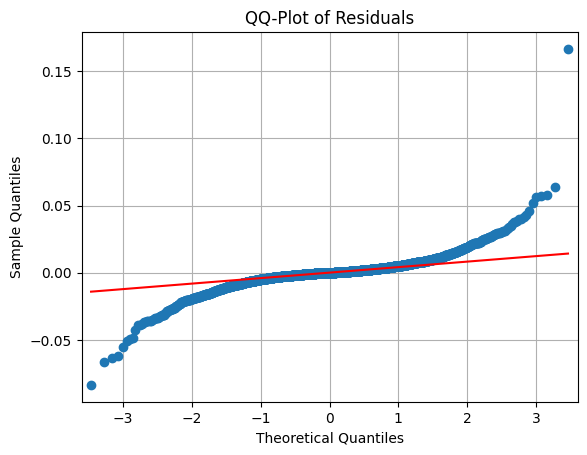

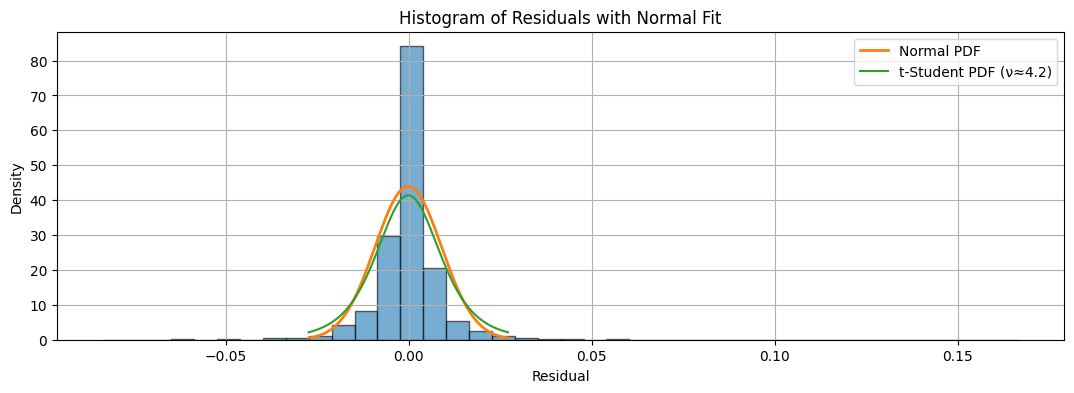


3. AUTOCORRELATION OF RESIDUALS


<Figure size 1300x400 with 0 Axes>

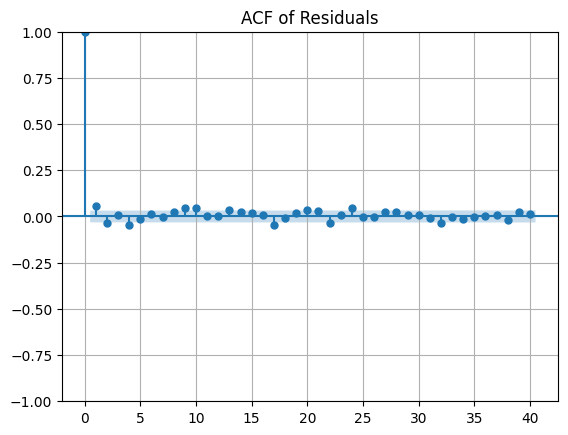

<Figure size 1300x400 with 0 Axes>

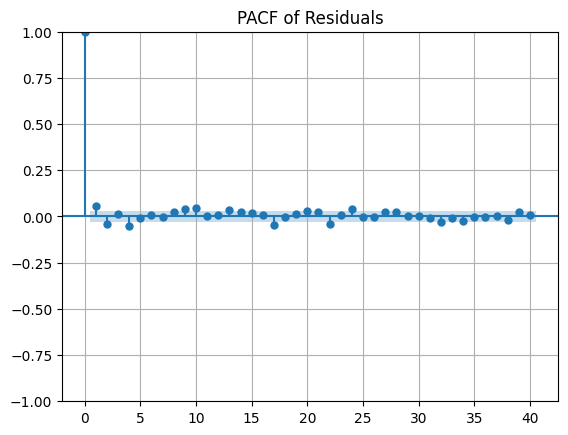


Durbin–Watson statistic
  H0: No autocorrelation in residuals
  H1: Autocorrelation present
  DW = 1.8842
  ~2 is good; <1.5 or >2.5 suggests autocorrelation.

Ljung–Box test on residuals:
      lb_stat     lb_pvalue
5   26.522201  7.065677e-05
10  44.863784  2.301290e-06
20  66.524078  6.657507e-07

H0: Residuals are independent (no autocorrelation)
H1: Residuals exhibit autocorrelation

  ➜ Reject H0 at lag 5: residual autocorrelation detected.
  ➜ Reject H0 at lag 10: residual autocorrelation detected.
  ➜ Reject H0 at lag 20: residual autocorrelation detected.


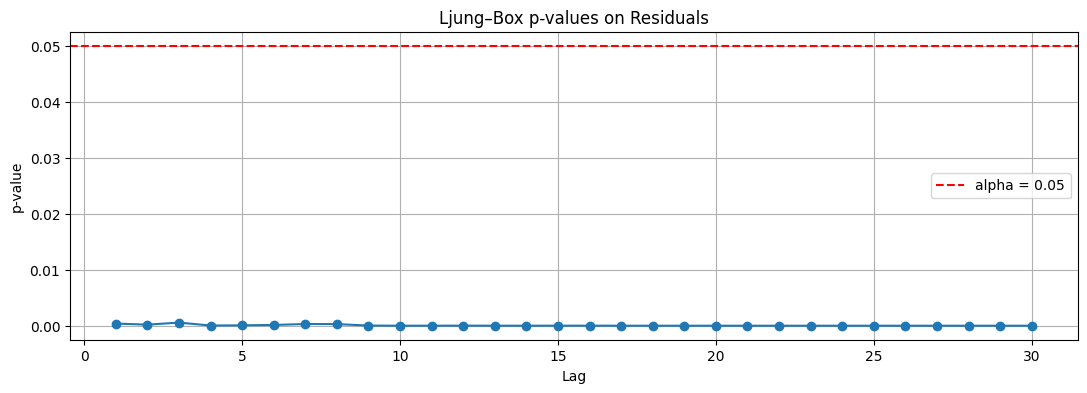


4. ARCH EFFECTS / VOLATILITY CLUSTERING


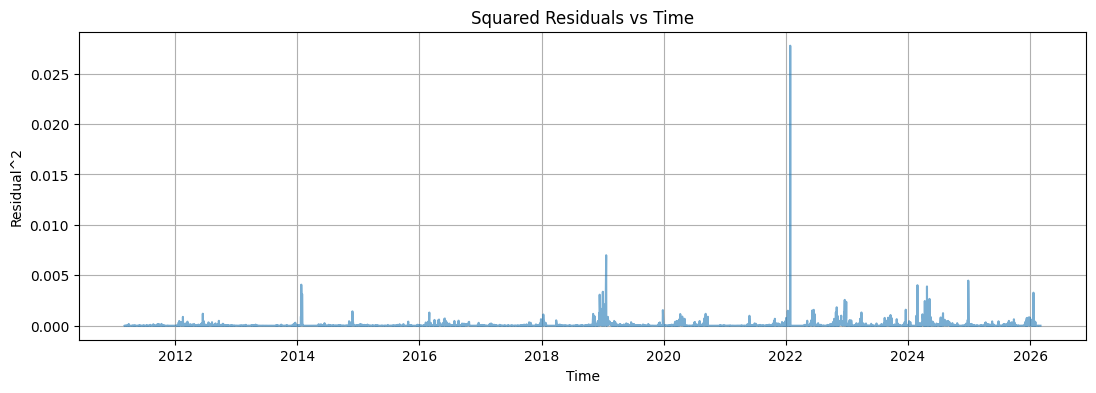

<Figure size 1300x400 with 0 Axes>

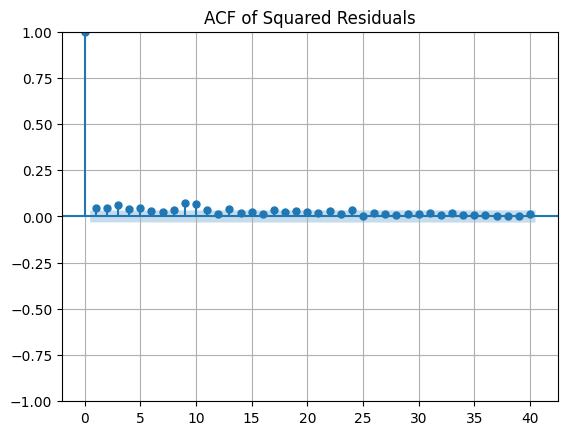

<Figure size 1300x400 with 0 Axes>

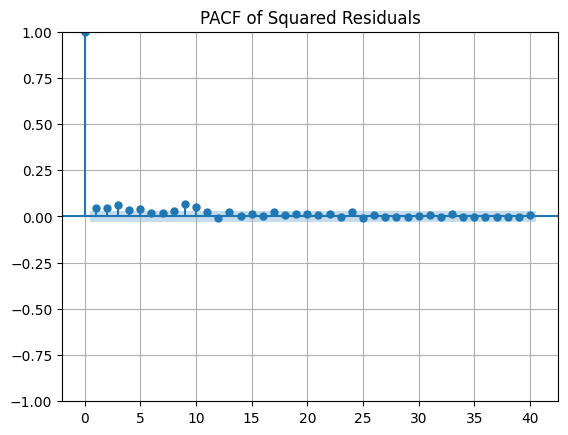


Ljung–Box test on squared residuals:
       lb_stat     lb_pvalue
5    46.529667  7.084577e-09
10   94.392572  7.176430e-16
20  125.335808  2.906359e-17

H0: No autocorrelation in squared residuals (no ARCH effects)
H1: Autocorrelation in squared residuals (ARCH effects present)

  ➜ Reject H0 for at least one lag: evidence of ARCH effects → consider GARCH modeling.


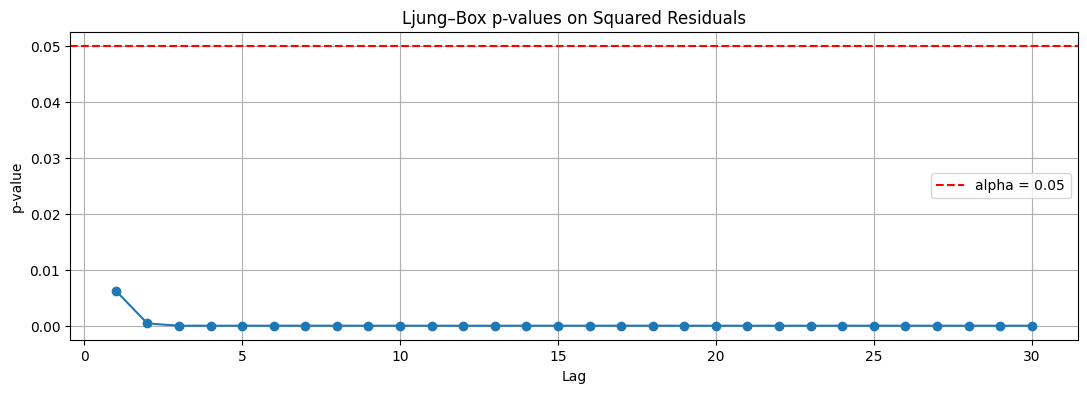


Time-series residual diagnostics complete.


M6 — Mid-Curve — Residual Diagnostics
Model type: ARIMA/ARX → expecting raw residuals ε_t.

1. RESIDUALS OVER TIME


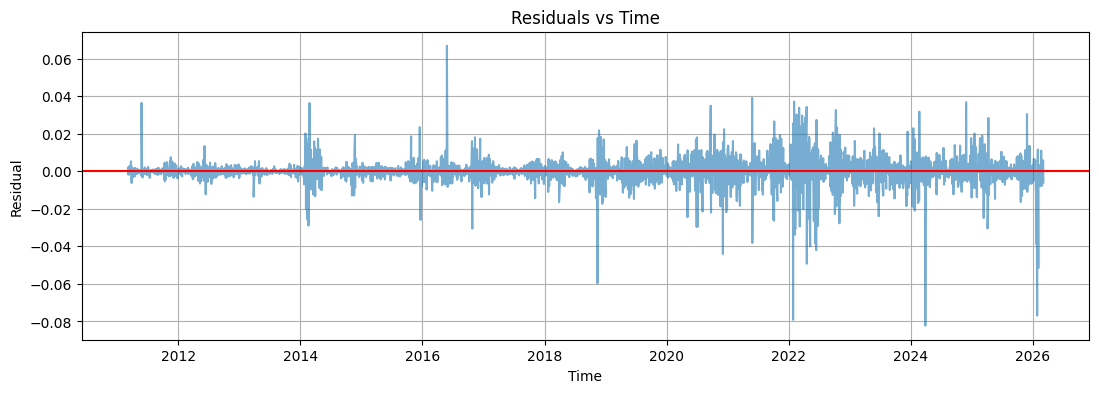


2. NORMALITY OF RESIDUALS

Shapiro–Wilk test
  H0: Residuals follow a normal distribution
  H1: Residuals are not normally distributed
  Statistic = 0.7860,  p-value = 0.0000
  ➜ Reject H0 → Residuals NOT normal

Jarque–Bera test
  H0: Residuals are normal (correct skewness + kurtosis)
  H1: Residuals are not normal
  Statistic = 85163.5723,  p-value = 0.0000
  ➜ Reject H0 → Residuals NOT normal (skew or heavy tails)


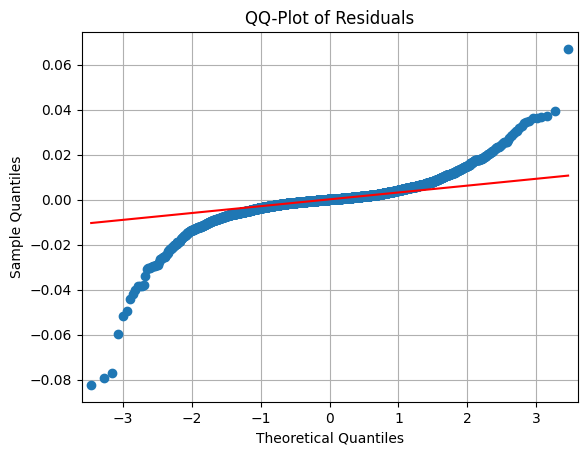

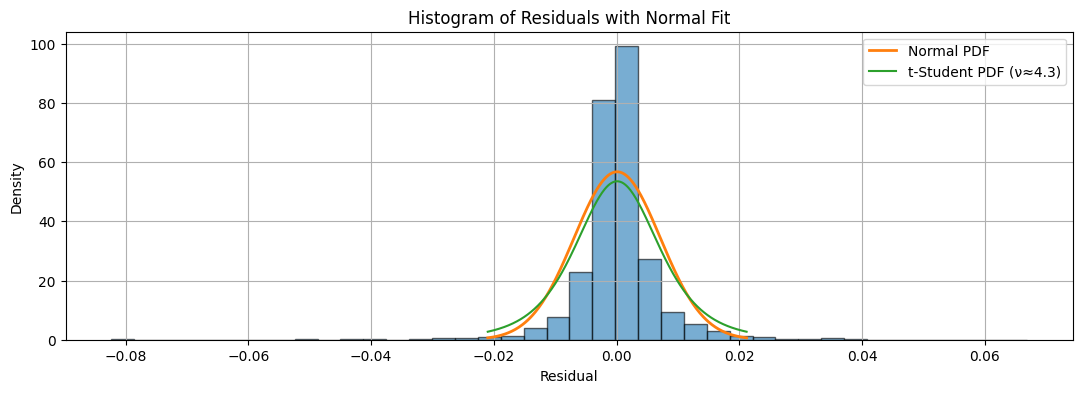


3. AUTOCORRELATION OF RESIDUALS


<Figure size 1300x400 with 0 Axes>

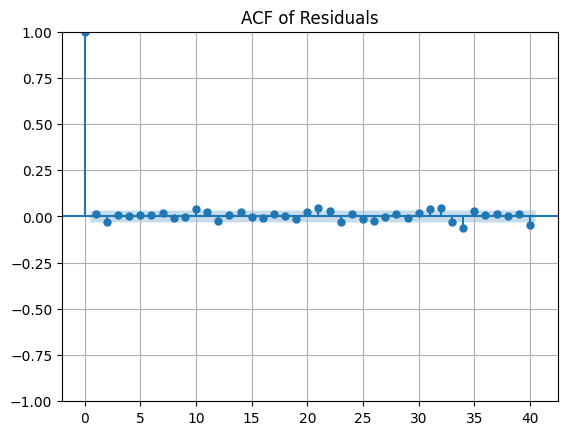

<Figure size 1300x400 with 0 Axes>

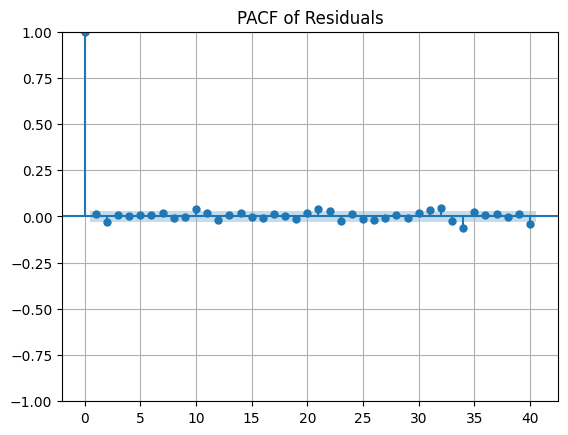


Durbin–Watson statistic
  H0: No autocorrelation in residuals
  H1: Autocorrelation present
  DW = 1.9689
  ~2 is good; <1.5 or >2.5 suggests autocorrelation.

Ljung–Box test on residuals:
      lb_stat  lb_pvalue
5    4.493226   0.480790
10  13.450562   0.199559
20  23.095024   0.284153

H0: Residuals are independent (no autocorrelation)
H1: Residuals exhibit autocorrelation

  ➜ Fail to reject H0 at lag 5: no evidence of autocorrelation at lag 5.
  ➜ Fail to reject H0 at lag 10: no evidence of autocorrelation at lag 10.
  ➜ Fail to reject H0 at lag 20: no evidence of autocorrelation at lag 20.


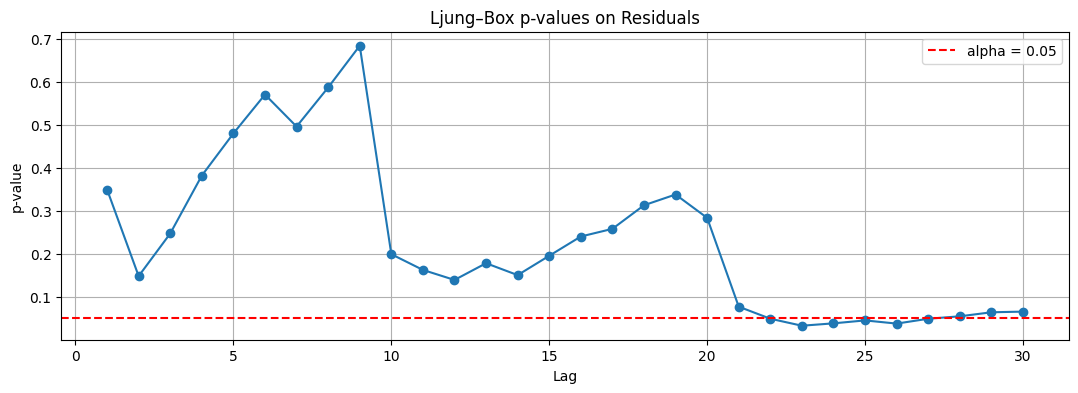


4. ARCH EFFECTS / VOLATILITY CLUSTERING


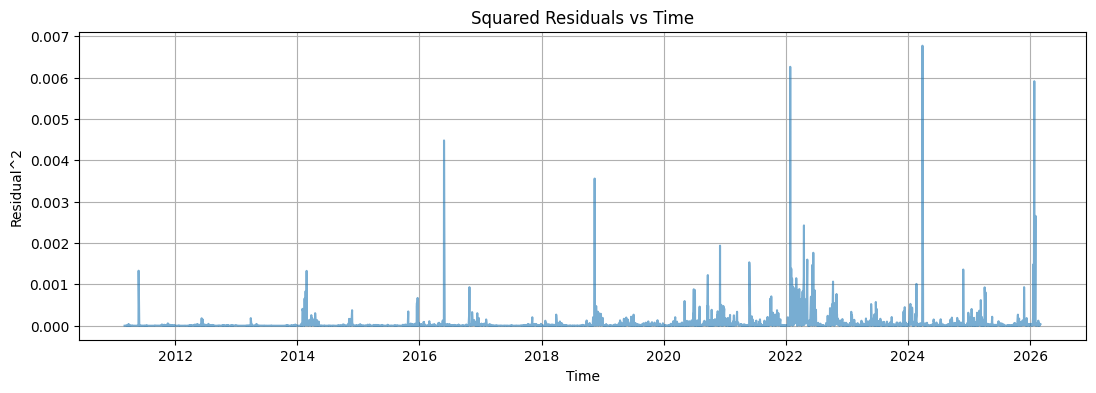

<Figure size 1300x400 with 0 Axes>

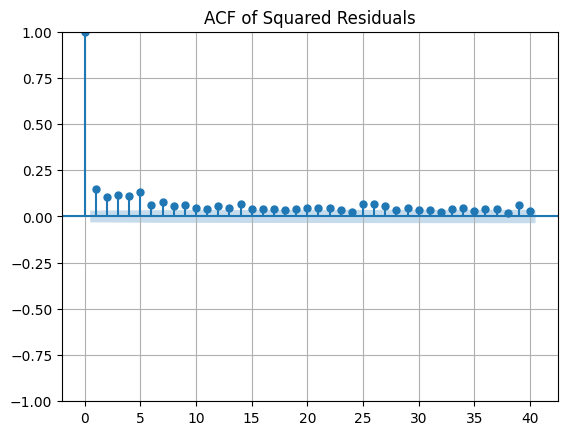

<Figure size 1300x400 with 0 Axes>

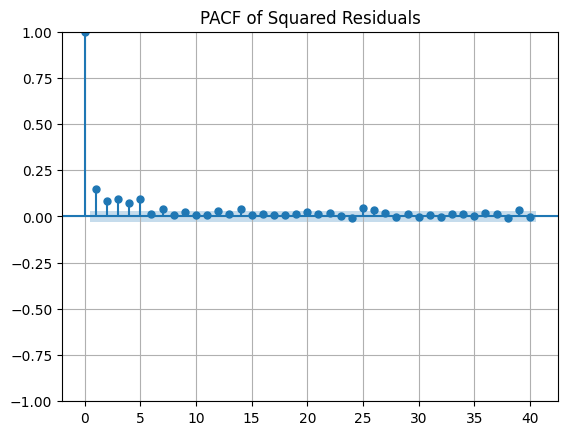


Ljung–Box test on squared residuals:
       lb_stat     lb_pvalue
5   288.582356  2.850152e-60
10  362.601909  8.414328e-72
20  444.543454  1.118604e-81

H0: No autocorrelation in squared residuals (no ARCH effects)
H1: Autocorrelation in squared residuals (ARCH effects present)

  ➜ Reject H0 for at least one lag: evidence of ARCH effects → consider GARCH modeling.


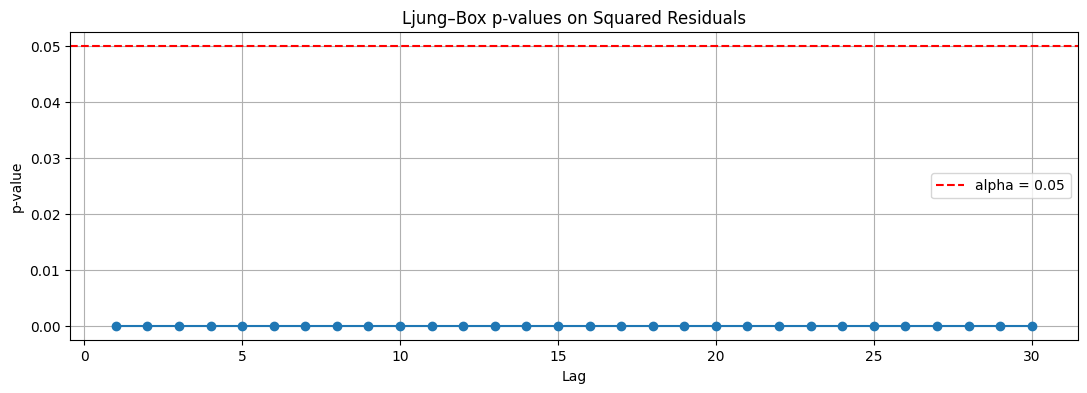


Time-series residual diagnostics complete.



In [52]:
from ts_diagnostics import ts_residual_diagnostics

# ACF/PACF, Ljung-Box, and ARCH effects for M1 and M6
# model_type='arima' = raw residuals ε_t (not standardised)
for mat, label in [("hh_1", "M1 — Front-End"), ("hh_6", "M6 — Mid-Curve")]:
    print("\n" + "=" * 70)
    print(f"{label} — Residual Diagnostics")
    print("=" * 70)
    ts_residual_diagnostics(
        df_residuals[mat].dropna(),
        model_type="arima",
        alpha=0.05,
        acf_lags=40,
        pacf_lags=40,
        ljung_lags=(5, 10, 20),
        lb_plot_start=1,
        lb_plot_end=30,
        show_plots=True,
        verbose=True,
        figsize=(13, 4),
    )

## Model Grid Search for Hyperparameter Tuning

In [53]:
from itertools import product
import numpy as np
import pandas as pd
import time

# ============================================================
# Robustness grid for rolling two-stage PCA specifications
# ============================================================

T_GRID = [126, 252, 504]
M_GRID = [3, 4]
TAU_FAST_GRID = [15, 21]
TAU_SLOW_GRID = [126, 252]

def evaluate_factor_spec(
    X_df,
    price_cols,
    T_window,
    tau_fast,
    tau_slow,
    p,
    m,
):
    """
    Run rolling two-stage PCA and compute compact diagnostics.

    Metrics:
        - mean / median R2 factor decomposition
        - mean / max absolute residual correlation
        - mean vol ratio residual/raw
        - mean residual volatility
        - loading stability
        - residual excess kurtosis
    """

    (
        df_factors_tmp,
        df_residuals_tmp,
        df_fitted_tmp,
        df_loadings_tmp,
        df_eigenvalues_tmp,
        df_diagnostics_tmp,
    ) = run_rolling_factor_model(
        X_df,
        T_window=T_window,
        tau_fast=tau_fast,
        tau_slow=tau_slow,
        p=p,
        m=m,
    )

    X_aligned = X_df.loc[df_residuals_tmp.index, price_cols]

    # -------------------------
    # R2 per maturity
    # -------------------------
    r2_values = []
    vol_ratios = []

    for col in price_cols:
        raw = X_aligned[col]
        eps = df_residuals_tmp[col]

        ss_tot = ((raw - raw.mean()) ** 2).sum()
        ss_res = (eps ** 2).sum()

        r2 = 1 - ss_res / ss_tot
        r2_values.append(r2)

        vol_ratios.append(eps.std() / raw.std())

    r2_values = np.array(r2_values)
    vol_ratios = np.array(vol_ratios)

    # -------------------------
    # Residual correlations
    # -------------------------
    corr_resid = df_residuals_tmp[price_cols].corr()
    off_diag = corr_resid.values[np.triu_indices(len(price_cols), k=1)]

    mean_abs_resid_corr = np.mean(np.abs(off_diag))
    max_abs_resid_corr = np.max(np.abs(off_diag))

    # -------------------------
    # Raw correlations for reference
    # -------------------------
    raw_corr = X_aligned.corr()
    raw_off_diag = raw_corr.values[np.triu_indices(len(price_cols), k=1)]
    mean_abs_raw_corr = np.mean(np.abs(raw_off_diag))

    # -------------------------
    # Loading stability
    # -------------------------
    cos_cols = [f"cos_sim_f{k+1}" for k in range(m)]
    cos_df = df_diagnostics_tmp[cos_cols].dropna()

    mean_cos = cos_df.mean().mean()
    pct_cos_below_099 = (cos_df < 0.99).mean().mean()

    # -------------------------
    # Residual distribution
    # -------------------------
    resid_stack = df_residuals_tmp[price_cols].stack().dropna()

    mean_abs_resid = resid_stack.abs().mean()
    resid_std_mean = df_residuals_tmp[price_cols].std().mean()
    resid_kurtosis_mean = df_residuals_tmp[price_cols].kurtosis().mean()

    # -------------------------
    # Explained variance
    # -------------------------
    cumevr_col = f"cumevr_{m}"
    avg_cumevr_m = (
        df_eigenvalues_tmp[cumevr_col].mean()
        if cumevr_col in df_eigenvalues_tmp.columns
        else np.nan
    )

    return {
        "T_window": T_window,
        "tau_fast": tau_fast,
        "tau_slow": tau_slow,
        "p": p,
        "m": m,

        "n_obs": len(df_residuals_tmp),

        "mean_R2": r2_values.mean(),
        "median_R2": np.median(r2_values),
        "min_R2": r2_values.min(),

        "mean_vol_ratio": vol_ratios.mean(),
        "max_vol_ratio": vol_ratios.max(),

        "mean_abs_resid_corr": mean_abs_resid_corr,
        "max_abs_resid_corr": max_abs_resid_corr,
        "mean_abs_raw_corr": mean_abs_raw_corr,
        "corr_reduction": mean_abs_raw_corr - mean_abs_resid_corr,

        "mean_cos_stability": mean_cos,
        "pct_cos_below_099": pct_cos_below_099,

        "mean_abs_resid": mean_abs_resid,
        "mean_resid_std": resid_std_mean,
        "mean_resid_kurtosis": resid_kurtosis_mean,

        "avg_cumevr_m": avg_cumevr_m,
    }


rows = []
t0 = time.time()

total_specs = 0

for T_window, m, tau_fast, tau_slow in product(
    T_GRID,
    M_GRID,
    TAU_FAST_GRID,
    TAU_SLOW_GRID,
):
    # Basic constraints
    if tau_fast >= tau_slow:
        continue
    if tau_slow > T_window:
        continue
    if m > len(price_cols):
        continue

    # Keep p at least m for stage-1 idio vol estimation
    # Simple choice: p = max(3, m), but capped by N
    p = min(len(price_cols), max(3, m))

    total_specs += 1

    try:
        print(
            f"Running spec {total_specs}: "
            f"T={T_window}, tau_fast={tau_fast}, tau_slow={tau_slow}, p={p}, m={m}"
        )

        metrics = evaluate_factor_spec(
            X_df=X_df,
            price_cols=price_cols,
            T_window=T_window,
            tau_fast=tau_fast,
            tau_slow=tau_slow,
            p=p,
            m=m,
        )

        rows.append(metrics)

    except Exception as e:
        print(
            f"FAILED spec: T={T_window}, tau_fast={tau_fast}, "
            f"tau_slow={tau_slow}, p={p}, m={m} | error={e}"
        )

elapsed = time.time() - t0

spec_results = pd.DataFrame(rows)

print(f"\nDone. Ran {len(spec_results)} successful specs in {elapsed:.1f}s.")
spec_results.head()

Running spec 1: T=126, tau_fast=15, tau_slow=126, p=3, m=3
Running spec 2: T=126, tau_fast=21, tau_slow=126, p=3, m=3
Running spec 3: T=126, tau_fast=15, tau_slow=126, p=4, m=4
Running spec 4: T=126, tau_fast=21, tau_slow=126, p=4, m=4
Running spec 5: T=252, tau_fast=15, tau_slow=126, p=3, m=3
Running spec 6: T=252, tau_fast=15, tau_slow=252, p=3, m=3


KeyboardInterrupt: 

In [101]:
spec_results.sort_values("mean_R2", ascending=False)

,T_window,tau_fast,tau_slow,p,m,n_obs,mean_R2,median_R2,min_R2,mean_vol_ratio,...,mean_abs_resid_corr,max_abs_resid_corr,mean_abs_raw_corr,corr_reduction,mean_cos_stability,pct_cos_below_099,mean_abs_resid,mean_resid_std,mean_resid_kurtosis,avg_cumevr_m
3,126,21,126,4,4,3903,0.974998,0.983166,0.914848,0.143963,...,0.244699,0.611787,0.904246,0.659547,0.988121,0.102255,0.001009,0.003011,576.001138,0.998312
2,126,15,126,4,4,3903,0.973713,0.983106,0.911843,0.148376,...,0.233019,0.593158,0.904246,0.671227,0.983310,0.138839,0.001042,0.003118,583.793800,0.998248
10,252,21,126,4,4,3777,0.973118,0.978628,0.916892,0.152100,...,0.239530,0.593071,0.903801,0.664270,0.989009,0.095736,0.001111,0.003220,480.686160,0.997268
8,252,15,126,4,4,3777,0.972010,0.980072,0.912038,0.156170,...,0.225744,0.587494,0.903801,0.678057,0.983610,0.138308,0.001136,0.003345,517.633563,0.997272
18,504,21,126,4,4,3525,0.971927,0.979396,0.915896,0.155163,...,0.245155,0.606185,0.900506,0.655351,0.988428,0.095772,0.001155,0.003297,463.784768,0.996665
19,504,21,252,4,4,3525,0.971899,0.981964,0.927311,0.157863,...,0.224718,0.618638,0.900506,0.675788,0.988277,0.096552,0.001216,0.003399,472.687866,0.996070
17,504,15,252,4,4,3525,0.971597,0.982470,0.923334,0.158724,...,0.221274,0.586963,0.900506,0.679232,0.982939,0.140536,0.001222,0.003429,483.498682,0.996103
11,252,21,252,4,4,3777,0.971286,0.977577,0.916163,0.159459,...,0.235315,0.591582,0.903801,0.668486,0.988961,0.093684,0.001174,0.003420,494.473116,0.997023
16,504,15,126,4,4,3525,0.970918,0.980365,0.911415,0.158734,...,0.229522,0.583973,0.900506,0.670984,0.982510,0.141104,0.001173,0.003407,511.128663,0.996661
9,252,15,252,4,4,3777,0.970752,0.979796,0.912406,0.160904,...,0.220685,0.574416,0.903801,0.683116,0.983423,0.137646,0.001191,0.003468,484.707971,0.997051


In [102]:
# Lower is better for residual correlation and vol ratio.
# Higher is better for R2 and loading stability.

display_cols = [
    "T_window", "tau_fast", "tau_slow", "p", "m",
    "mean_R2", "median_R2", "min_R2",
    "mean_vol_ratio", "max_vol_ratio",
    "mean_abs_resid_corr", "max_abs_resid_corr",
    "corr_reduction",
    "mean_cos_stability", "pct_cos_below_099",
    "avg_cumevr_m",
]

spec_results_sorted = (
    spec_results
    .sort_values(
        by=[
            "mean_abs_resid_corr",
            "mean_vol_ratio",
            "mean_R2",
            "pct_cos_below_099",
        ],
        ascending=[True, True, False, True],
    )
)

spec_results_sorted[display_cols].round(4).head(20)

,T_window,tau_fast,tau_slow,p,m,mean_R2,median_R2,min_R2,mean_vol_ratio,max_vol_ratio,mean_abs_resid_corr,max_abs_resid_corr,corr_reduction,mean_cos_stability,pct_cos_below_099,avg_cumevr_m
9,252,15,252,4,4,0.9708,0.9798,0.9124,0.1609,0.2959,0.2207,0.5744,0.6831,0.9834,0.1376,0.9971
17,504,15,252,4,4,0.9716,0.9825,0.9233,0.1587,0.2768,0.2213,0.5870,0.6792,0.9829,0.1405,0.9961
19,504,21,252,4,4,0.9719,0.9820,0.9273,0.1579,0.2696,0.2247,0.6186,0.6758,0.9883,0.0966,0.9961
8,252,15,126,4,4,0.9720,0.9801,0.9120,0.1562,0.2965,0.2257,0.5875,0.6781,0.9836,0.1383,0.9973
1,126,21,126,3,3,0.9667,0.9777,0.9026,0.1692,0.3121,0.2273,0.6458,0.6770,0.9933,0.0574,0.9953
16,504,15,126,4,4,0.9709,0.9804,0.9114,0.1587,0.2976,0.2295,0.5840,0.6710,0.9825,0.1411,0.9967
0,126,15,126,3,3,0.9658,0.9787,0.9002,0.1719,0.3159,0.2298,0.6677,0.6745,0.9913,0.0788,0.9950
2,126,15,126,4,4,0.9737,0.9831,0.9118,0.1484,0.2969,0.2330,0.5932,0.6712,0.9833,0.1388,0.9982
11,252,21,252,4,4,0.9713,0.9776,0.9162,0.1595,0.2895,0.2353,0.5916,0.6685,0.9890,0.0937,0.9970
5,252,15,252,3,3,0.9594,0.9712,0.8837,0.1916,0.3410,0.2364,0.5811,0.6674,0.9913,0.0818,0.9922


In [103]:
def zscore_series(s):
    return (s - s.mean()) / s.std(ddof=0)

spec_rank = spec_results.copy()

# Good metrics:
# high mean_R2, high corr_reduction, high mean_cos_stability
# low mean_vol_ratio, low mean_abs_resid_corr, low pct_cos_below_099

spec_rank["score"] = (
    + zscore_series(spec_rank["mean_R2"])
    + zscore_series(spec_rank["corr_reduction"])
    + zscore_series(spec_rank["mean_cos_stability"])
    - zscore_series(spec_rank["mean_vol_ratio"])
    - zscore_series(spec_rank["mean_abs_resid_corr"])
    - zscore_series(spec_rank["pct_cos_below_099"])
)

spec_rank_sorted = spec_rank.sort_values("score", ascending=False)

spec_rank_sorted[	['T_window', 'tau_fast', 'tau_slow', 'p', 'm'] + ["score"]].round(4).head(20)

,T_window,tau_fast,tau_slow,p,m,score
1,126,21,126,3,3,4.3877
19,504,21,252,4,4,3.5879
0,126,15,126,3,3,2.2260
9,252,15,252,4,4,1.9777
17,504,15,252,4,4,1.5049
11,252,21,252,4,4,1.4637
8,252,15,126,4,4,1.2872
10,252,21,126,4,4,1.1616
3,126,21,126,4,4,0.3498
2,126,15,126,4,4,0.2580


In [104]:
baseline_mask = (
    (spec_results["T_window"] == 252)
    & (spec_results["tau_fast"] == 15)
    & (spec_results["tau_slow"] == 126)
    & (spec_results["m"] == 3)
)

baseline_result = spec_results.loc[baseline_mask, display_cols]

baseline_result.round(4)

,T_window,tau_fast,tau_slow,p,m,mean_R2,median_R2,min_R2,mean_vol_ratio,max_vol_ratio,mean_abs_resid_corr,max_abs_resid_corr,corr_reduction,mean_cos_stability,pct_cos_below_099,avg_cumevr_m
4,252,15,126,3,3,0.9611,0.9735,0.8846,0.1868,0.3397,0.2409,0.5857,0.6629,0.9908,0.0837,0.9928


In [105]:
summary_by_m = (
    spec_results
    .groupby("m")
    .agg({
        "mean_R2": "mean",
        "min_R2": "mean",
        "mean_vol_ratio": "mean",
        "mean_abs_resid_corr": "mean",
        "max_abs_resid_corr": "mean",
        "mean_cos_stability": "mean",
        "pct_cos_below_099": "mean",
        "avg_cumevr_m": "mean",
    })
    .round(4)
)

summary_by_m

,mean_R2,min_R2,mean_vol_ratio,mean_abs_resid_corr,max_abs_resid_corr,mean_cos_stability,pct_cos_below_099,avg_cumevr_m
m,,,,,,,,
3,0.9617,0.8896,0.1847,0.2384,0.6017,0.9925,0.0684,0.9925
4,0.9722,0.9162,0.1551,0.2320,0.5947,0.9859,0.1180,0.9971


In [95]:
summary_by_T = (
    spec_results
    .groupby("T_window")
    .agg({
        "mean_R2": "mean",
        "min_R2": "mean",
        "mean_vol_ratio": "mean",
        "mean_abs_resid_corr": "mean",
        "max_abs_resid_corr": "mean",
        "mean_cos_stability": "mean",
        "pct_cos_below_099": "mean",
        "avg_cumevr_m": "mean",
    })
    .round(4)
)

summary_by_T

,mean_R2,min_R2,mean_vol_ratio,mean_abs_resid_corr,max_abs_resid_corr,mean_cos_stability,pct_cos_below_099,avg_cumevr_m
T_window,,,,,,,,
126,0.8574,0.7131,0.3617,0.1841,0.5286,0.9800,0.1017,0.9773
252,0.8669,0.7181,0.3495,0.1704,0.5237,0.9780,0.1124,0.9594
504,0.8631,0.7082,0.3536,0.1699,0.5103,0.9788,0.1088,0.9559
